In [1]:
# For data analysis and predictions
import numpy as np
import pandas as pd

# For preprocessing and error detection
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# For data Training (RNN, CNN, LSTM)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, SimpleRNN, LSTM, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError

# For Vector Auto Regression
from statsmodels.tsa.vector_ar.var_model import VAR

# For data visualize
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
csvData = pd.read_csv("./RawData/ADANIPORTS.csv", index_col=['Date'], parse_dates=['Date']);
df = pd.DataFrame(csvData);
df = df.drop(columns=['Trades', 'Series', 'Symbol']);

In [3]:
# display the columns in dataframe
print(df.columns);

# display how many data in csv file (row, column)
print(df.shape);

Index(['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume',
       'Turnover', 'Deliverable Volume', '%Deliverble'],
      dtype='object')
(3322, 11)


In [4]:
# display the variable types of column
print(df.dtypes);

Prev Close            float64
Open                  float64
High                  float64
Low                   float64
Last                  float64
Close                 float64
VWAP                  float64
Volume                  int64
Turnover              float64
Deliverable Volume      int64
%Deliverble           float64
dtype: object


In [5]:
print(df.head());

            Prev Close    Open     High    Low   Last   Close    VWAP  \
Date                                                                    
2007-11-27      440.00  770.00  1050.00  770.0  959.0  962.90  984.72   
2007-11-28      962.90  984.00   990.00  874.0  885.0  893.90  941.38   
2007-11-29      893.90  909.00   914.75  841.0  887.0  884.20  888.09   
2007-11-30      884.20  890.00   958.00  890.0  929.0  921.55  929.17   
2007-12-03      921.55  939.75   995.00  922.0  980.0  969.30  965.65   

              Volume      Turnover  Deliverable Volume  %Deliverble  
Date                                                                 
2007-11-27  27294366  2.687719e+15             9859619       0.3612  
2007-11-28   4581338  4.312765e+14             1453278       0.3172  
2007-11-29   5124121  4.550658e+14             1069678       0.2088  
2007-11-30   4609762  4.283257e+14             1260913       0.2735  
2007-12-03   2977470  2.875200e+14              816123       0.2741 

In [6]:
print(df.describe());

        Prev Close         Open         High          Low         Last  \
count  3322.000000  3322.000000  3322.000000  3322.000000  3322.000000   
mean    344.114314   344.763019   351.608007   337.531969   344.239539   
std     192.936882   193.619992   198.617808   188.676614   193.187813   
min     108.000000   108.000000   110.450000   105.650000   108.000000   
25%     164.312500   164.850000   168.000000   161.600000   164.075000   
50%     324.700000   325.750000   331.275000   319.850000   325.000000   
75%     400.912500   401.000000   407.187500   395.000000   400.912500   
max    1307.450000  1310.250000  1324.000000  1270.000000  1308.000000   

             Close         VWAP        Volume      Turnover  \
count  3322.000000  3322.000000  3.322000e+03  3.322000e+03   
mean    344.201626   344.853182  2.954564e+06  1.070144e+14   
std     193.045886   193.841305  4.104227e+06  2.625564e+14   
min     108.000000   108.340000  1.236600e+04  2.415857e+11   
25%     164.312500

In [7]:
print(df);

            Prev Close    Open     High     Low   Last   Close    VWAP  \
Date                                                                     
2007-11-27      440.00  770.00  1050.00  770.00  959.0  962.90  984.72   
2007-11-28      962.90  984.00   990.00  874.00  885.0  893.90  941.38   
2007-11-29      893.90  909.00   914.75  841.00  887.0  884.20  888.09   
2007-11-30      884.20  890.00   958.00  890.00  929.0  921.55  929.17   
2007-12-03      921.55  939.75   995.00  922.00  980.0  969.30  965.65   
...                ...     ...      ...     ...    ...     ...     ...   
2021-04-26      725.35  733.00   739.65  728.90  729.2  730.75  733.25   
2021-04-27      730.75  735.00   757.50  727.35  748.6  749.15  747.67   
2021-04-28      749.15  755.00   760.00  741.10  743.4  746.25  751.02   
2021-04-29      746.25  753.20   765.85  743.40  746.4  746.75  753.06   
2021-04-30      746.75  739.00   759.45  724.50  726.4  730.05  743.35   

              Volume      Turnover  D

In [8]:
# function for box plot
def plot_boxplot(data, column):
    sns.boxplot(data=data, x=column);
    sns.despine();
    plt.title(f"Boxplot of {column}");
    plt.show();
    
# Define function to plot correlation heatmap
def plot_heatmap(data, title):
    sns.heatmap(data.corr(), cmap='coolwarm', annot=True);
    plt.title(title);
    sns.despine();
    plt.show();

# function for plot pair plot
def plot_pairplot(data, columns):
    sns.pairplot(data=data, vars=columns);
    sns.despine();
    plt.show();

def plot_timeSeries(dataframe, columns):
    for column in columns: 
        plt.figure(figsize=(16, 4));
        plt.plot(dataframe[column]);
        plt.title(f'{column} of Adani ports stock data');
        plt.ylabel(f"{column}");
        plt.xlabel('Trading Year');
        plt.grid(False);
        plt.show();

In [9]:
# All the data relate to stock price
priceData = ['Prev Close', 'Open', 'High', 'Low', 'Close', 'VWAP'];

# All the data relate to stock volume
volumeData = ['Volume', 'Turnover', 'Deliverable Volume', '%Deliverble'];

# Normalize data 
All_Columns = priceData + volumeData;

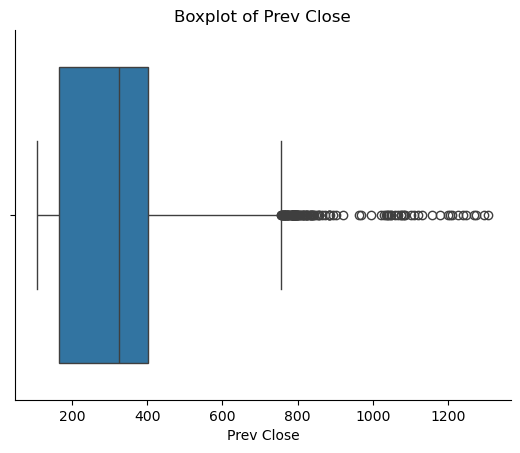

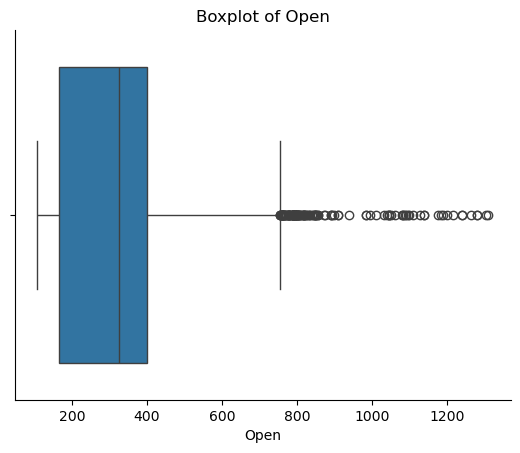

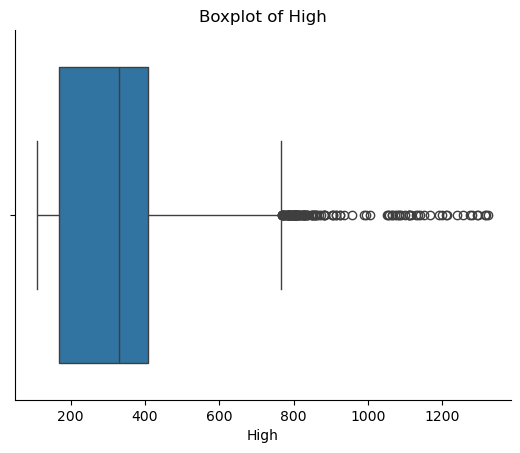

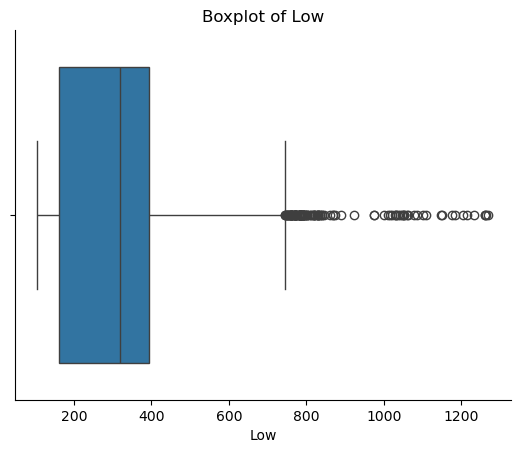

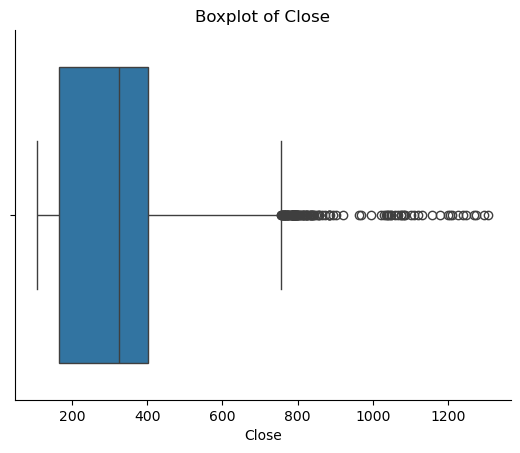

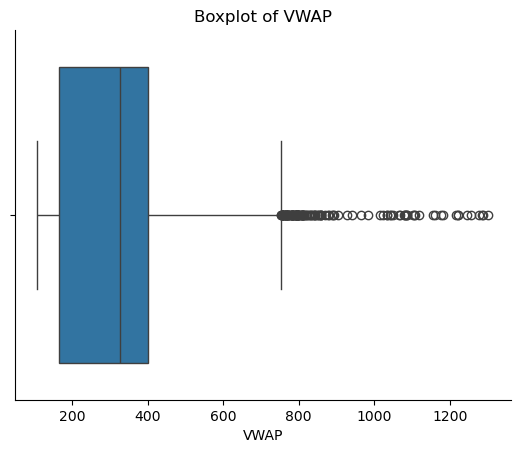

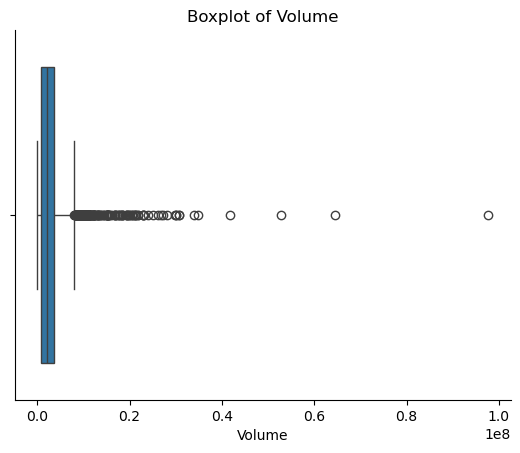

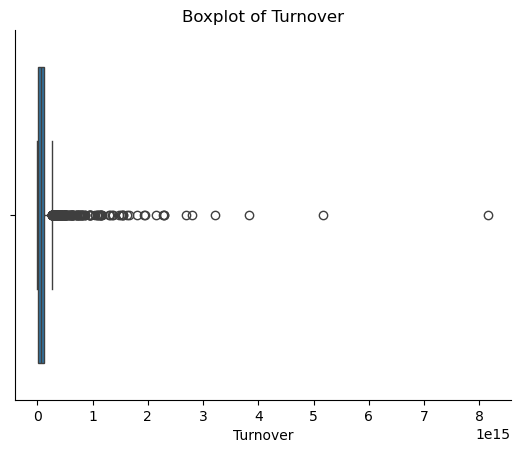

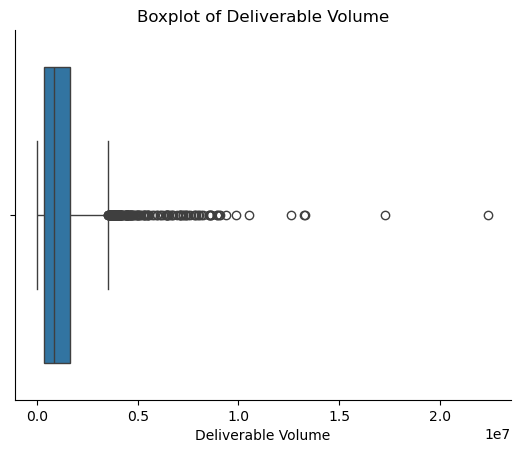

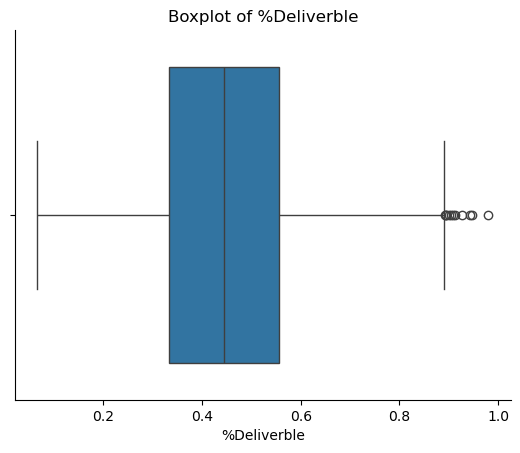

In [10]:
# Loop through each column to plot boxplots 
for column in All_Columns: 
    plot_boxplot(df, column);

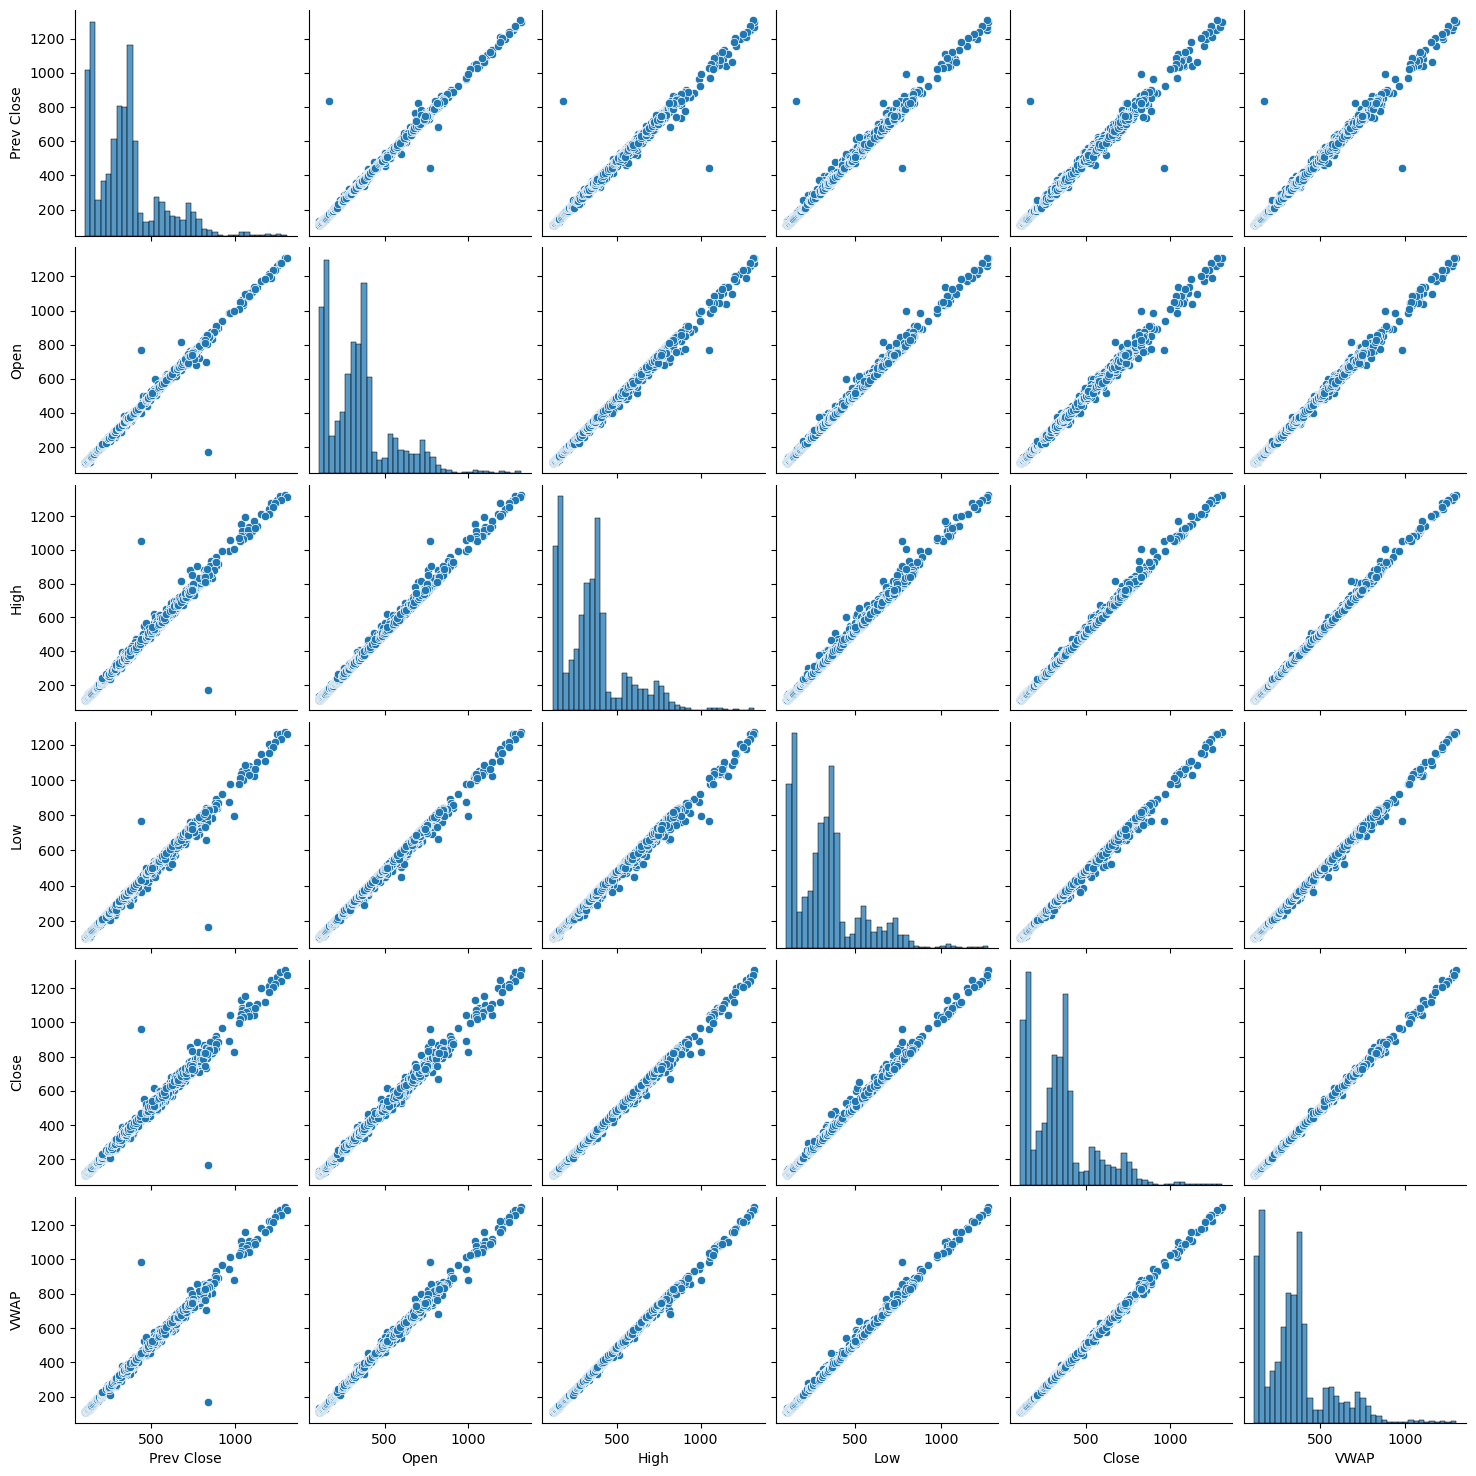

In [11]:
# For price data
plot_pairplot(df, priceData);

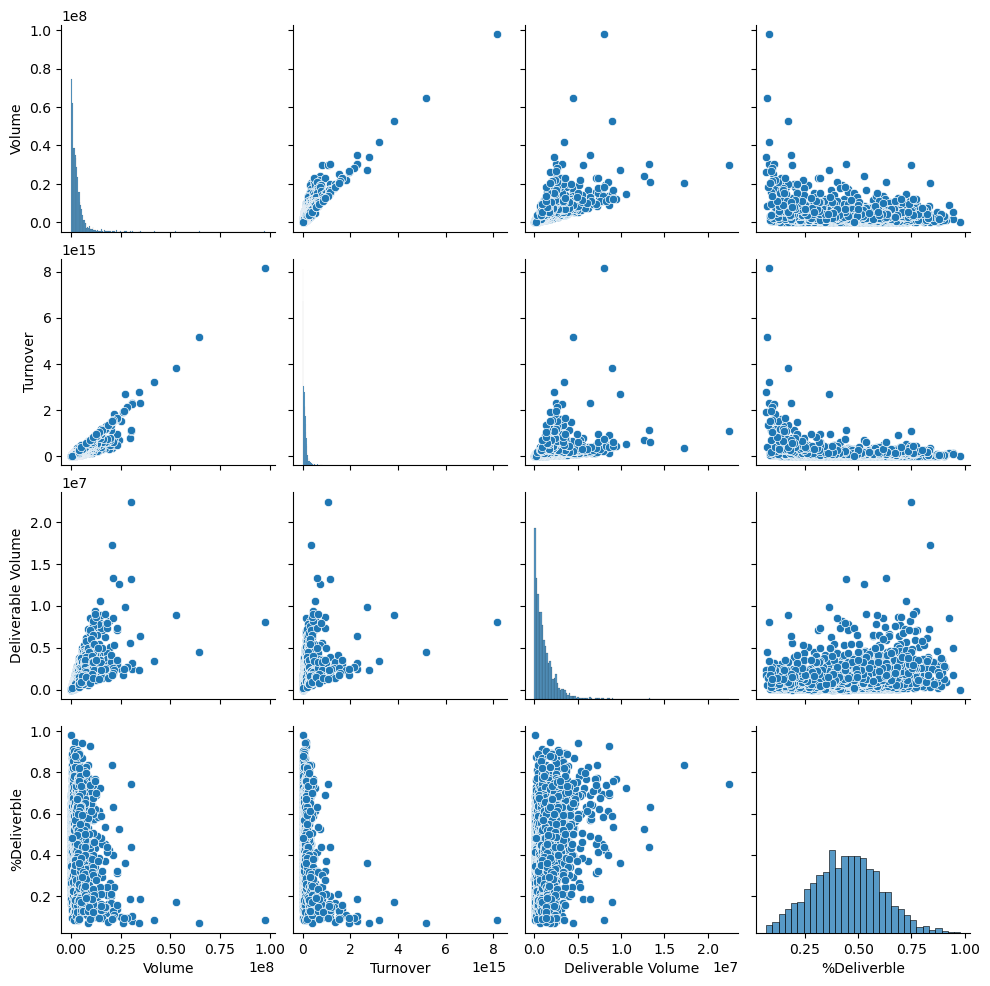

In [12]:
# For volume data
plot_pairplot(df, volumeData);

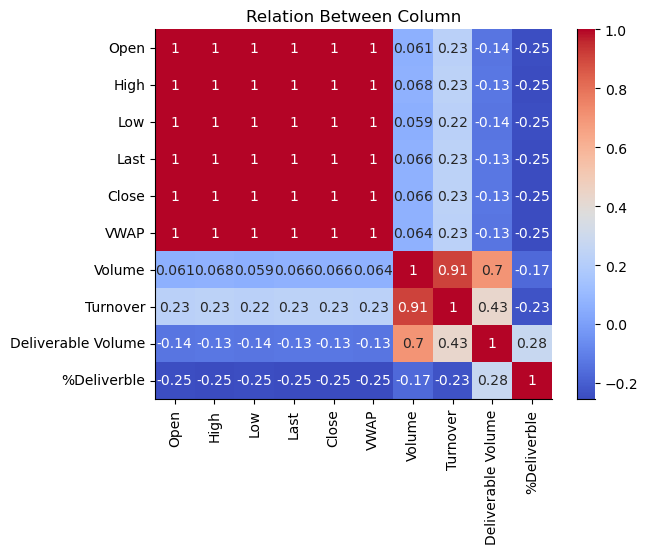

In [13]:
plot_heatmap(df.iloc[:,1:], 'Relation Between Column');

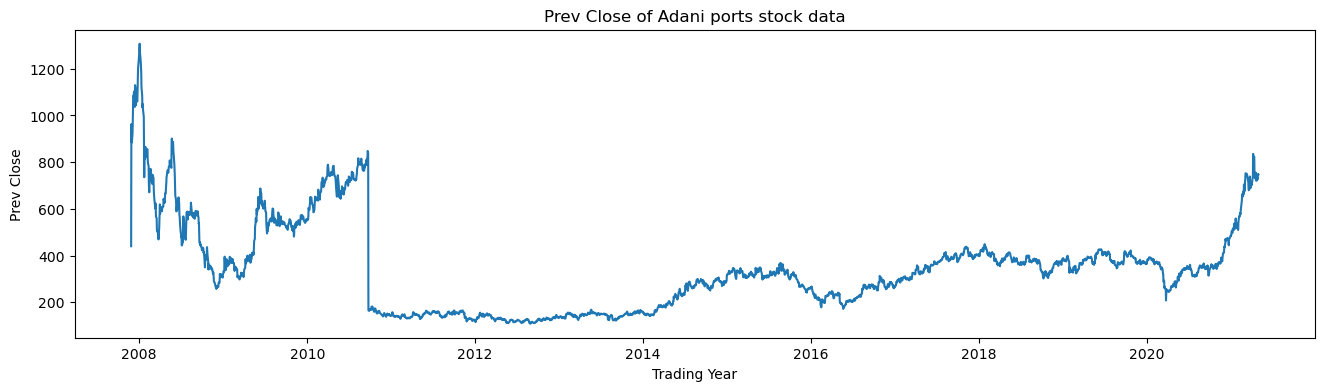

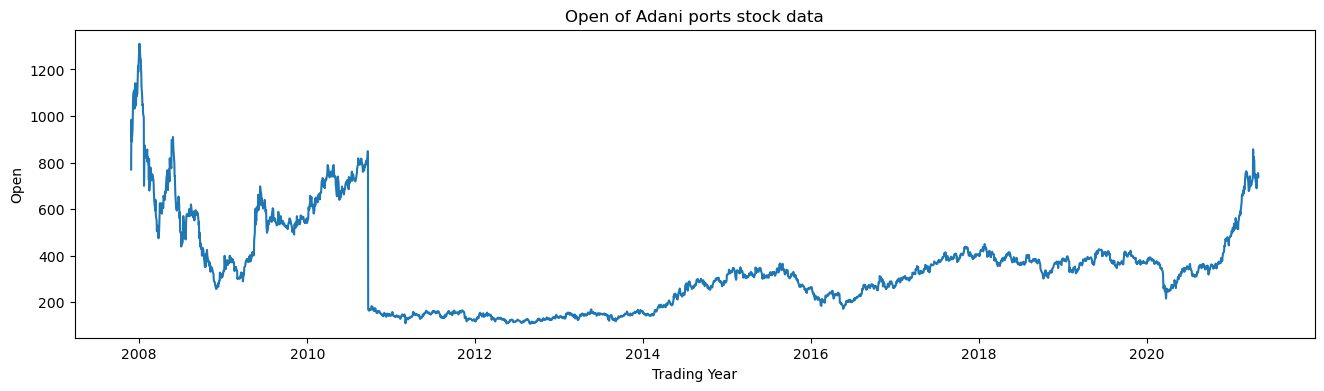

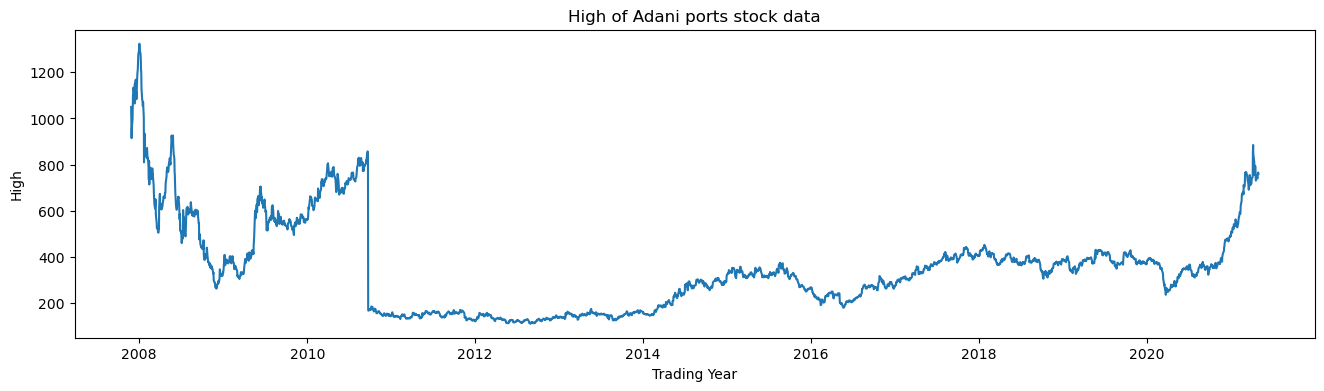

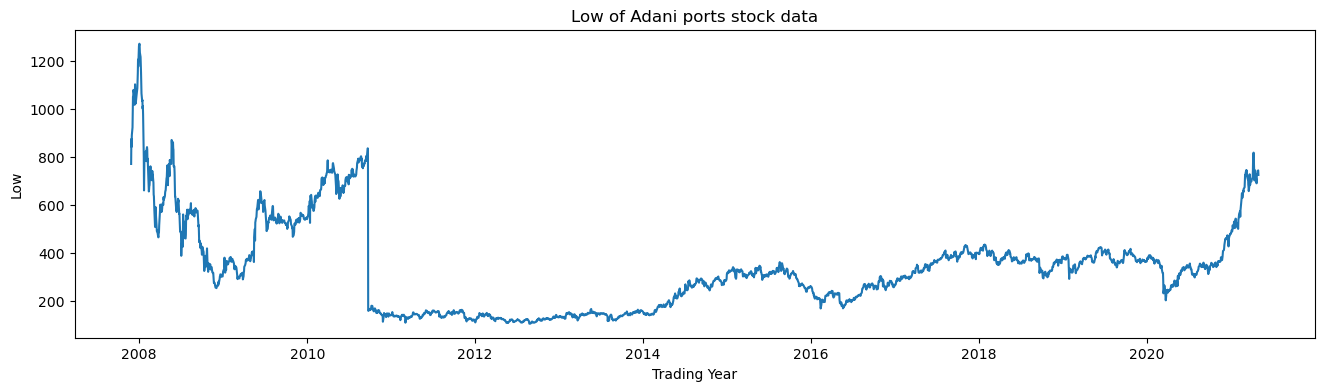

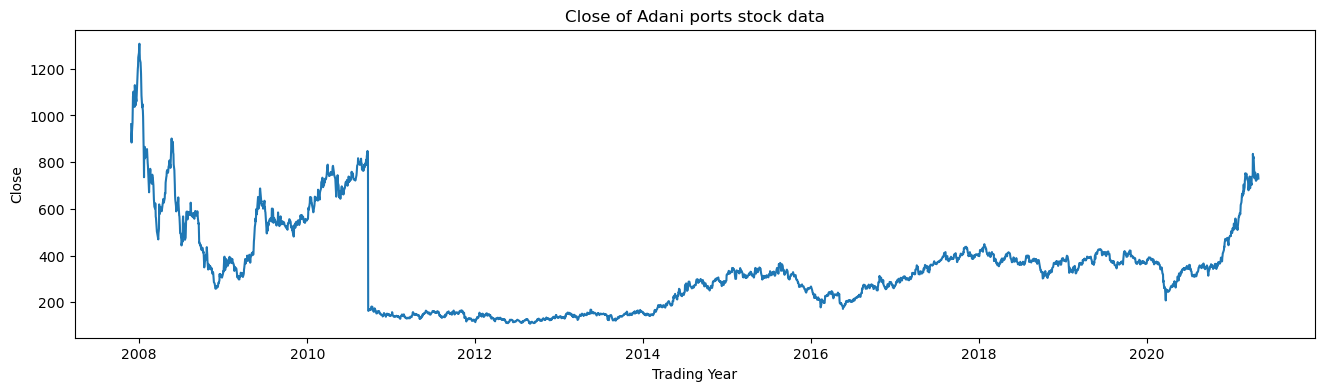

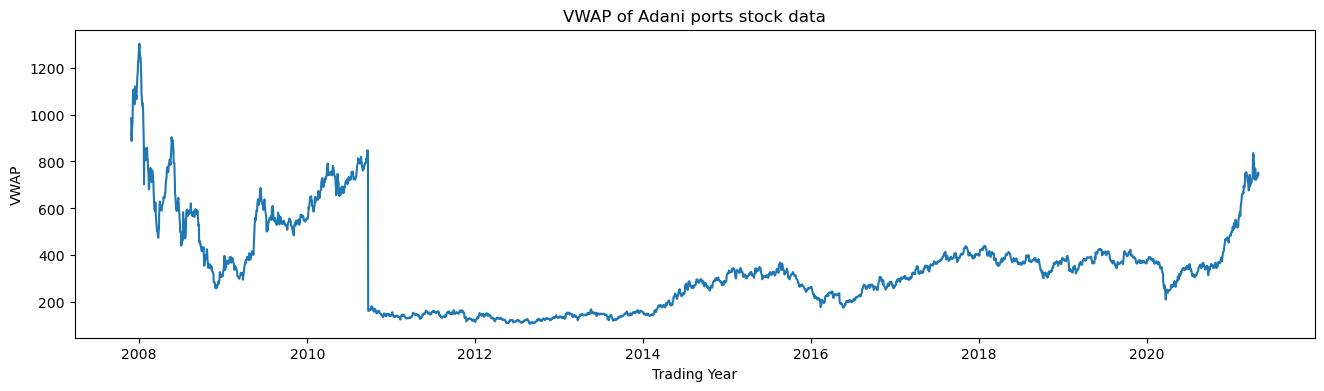

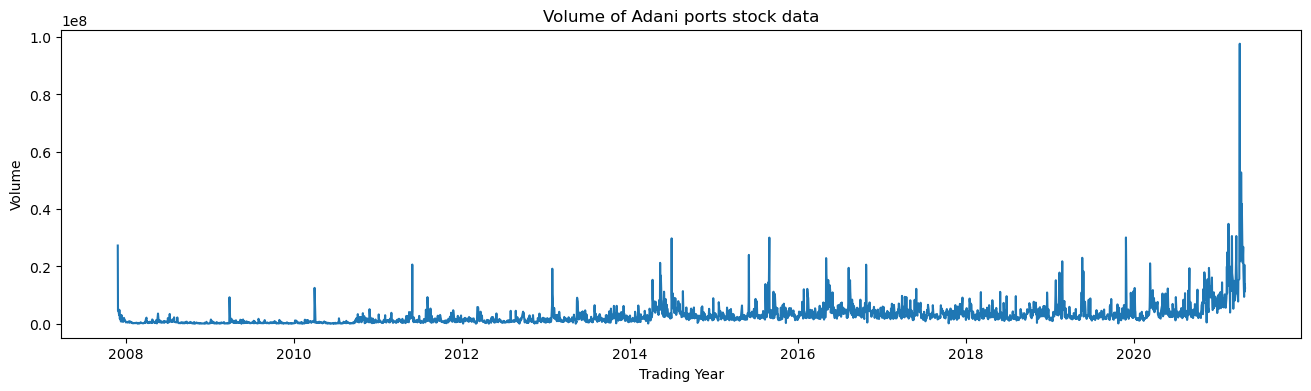

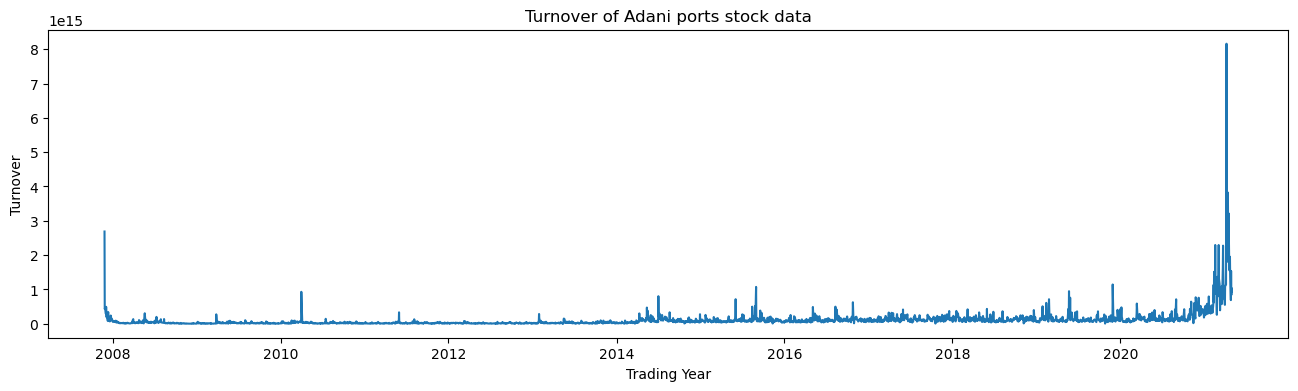

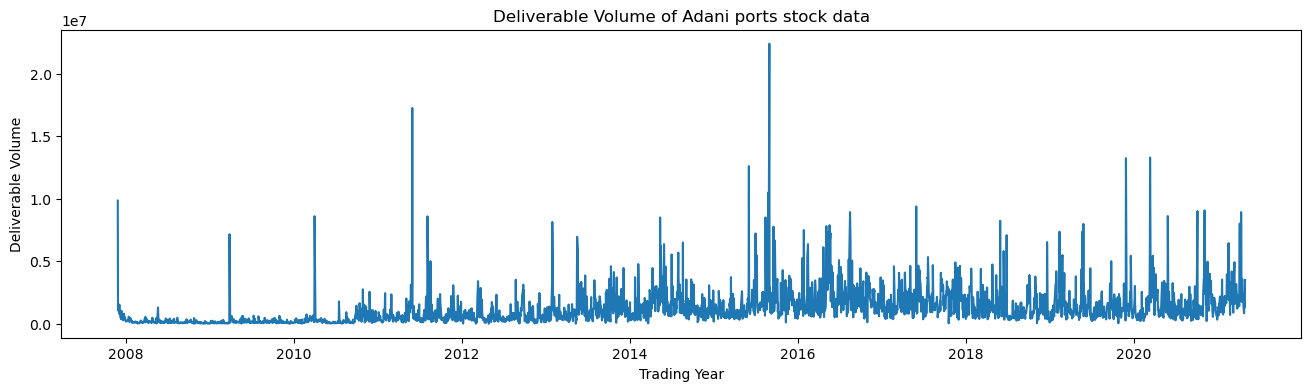

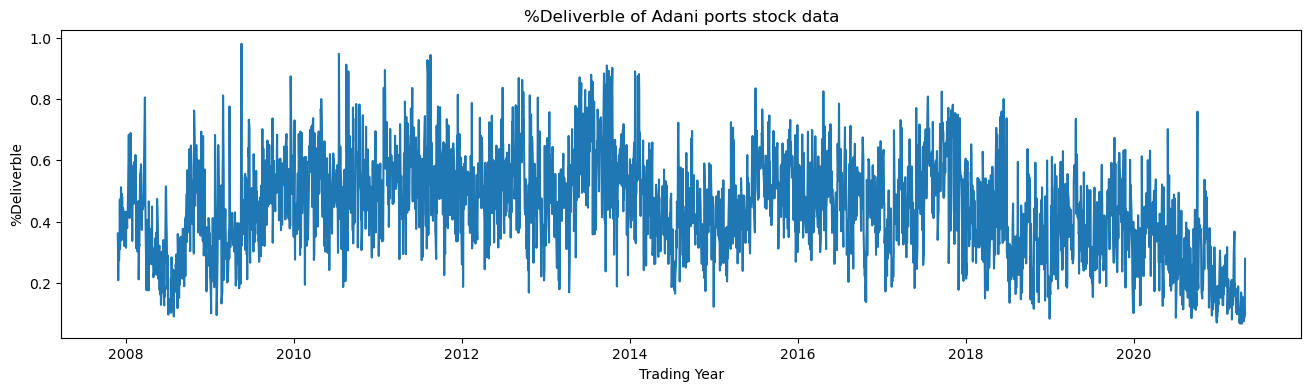

In [14]:
# print all data time series
plot_timeSeries(df, All_Columns);

In [15]:
# Scaling the data based on highest and lowest value
scaler = MinMaxScaler();
scaled_data = scaler.fit_transform(df[All_Columns]);
scaled_df = pd.DataFrame(scaled_data, columns=All_Columns, index=df.index);
print(scaled_df.head());

            Prev Close      Open      High       Low     Close      VWAP  \
Date                                                                       
2007-11-27    0.276794  0.550634  0.774216  0.570576  0.712743  0.734103   
2007-11-28    0.712743  0.728634  0.724774  0.659896  0.655217  0.697799   
2007-11-29    0.655217  0.666251  0.662766  0.631554  0.647130  0.653161   
2007-11-30    0.647130  0.650447  0.698406  0.673638  0.678269  0.687572   
2007-12-03    0.678269  0.691828  0.728895  0.701121  0.718079  0.718129   

              Volume  Turnover  Deliverable Volume  %Deliverble  
Date                                                             
2007-11-27  0.279227  0.329318            0.439703     0.322305  
2007-11-28  0.046763  0.052818            0.064606     0.274102  
2007-11-29  0.052318  0.055733            0.047490     0.155346  
2007-11-30  0.047054  0.052456            0.056023     0.226227  
2007-12-03  0.030347  0.035202            0.036176     0.226884  


In [16]:
# Function to labeling data
def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(len(data)- seq_length):
        sequences.append(data[i:i + seq_length]);
        labels.append(data[i + seq_length]);
    return np.array(sequences), np.array(labels);

# To scaling the data with MinMaxScalerA
def inverse_transform_predictions(predictions): 
    return scaler.inverse_transform(predictions);

# Print the top 5 rows predictions data  
def print_shape_result(df):
    print("Predicted Results:");
    print(predictions_df.head());
    print(predictions_df.shape);

#It used to print Time Series plot with predict dataframe and actual dataframe
def time_series_plot(Model, column, predictDF):
    # these part are used to combine actual data and predict data
    comparison_df = pd.DataFrame({ 
        'Actual': actual_last_20[column].values, 
        'Predicted': predictDF[column].values 
    }, index=actual_last_20.index);
    
    # Plot actual and predicted values
    plot_time_series(comparison_df['Actual'], comparison_df['Predicted'], f"{column} - Actual vs Predicted ({Model})");

# Plot actual and predicted values
def plot_time_series(actual_series, predicted_series, title): 
    plt.figure(figsize=(16, 6));
    plt.plot(actual_series.index, actual_series, label='Actual');
    plt.plot(predicted_series.index, predicted_series, linestyle='--', label='Predicted');
    plt.title(title);
    plt.xlabel('Date');
    plt.ylabel('Value');
    plt.legend(loc='best');
    plt.grid(True);
    plt.show();

def plot_time_series_all(actual_series, model_data_map, column, best_model_name):
    plt.figure(figsize=(16, 6))
    plt.plot(actual_series.index, actual_series, label='Actual', color='black')
    
    for model_name, model_series in model_data_map.items():
        if model_name == best_model_name:
            plt.plot(model_series.index, model_series, linestyle='--', linewidth=2.5, label=f'{model_name} (Best)', color='red')
        else:
            plt.plot(model_series.index, model_series, linestyle='--', alpha=0.5, label=model_name)
    
    plt.title(f"{column} - Actual vs Predicted (Best: {best_model_name})")
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

    plt.show();

In [17]:
# Define sequence length 
seq_length = 60;

# Create sequences 
sequences, labels = create_sequences(scaled_df.values, seq_length);

In [18]:
# Split data as 80 for training/20 for testing
num_training_samples = int(0.8 * len(sequences));
X_train, X_test = sequences[:num_training_samples], sequences[num_training_samples:];
y_train, y_test = labels[:num_training_samples], sequences[num_training_samples:];

print(f"Training sequences shape: {X_train.shape}");
print(f"Training labels shape: {y_train.shape}");
print(f"Testing sequences shape: {X_test.shape}");
print(f"Testing labels shape: {y_test.shape}")

Training sequences shape: (2609, 60, 10)
Training labels shape: (2609, 10)
Testing sequences shape: (653, 60, 10)
Testing labels shape: (653, 60, 10)


In [19]:
# Capture last 20% of data for compare the predict result 
num_samples = len(X_test)
actual_last_20 = df.iloc[-num_samples: -1]

# Callbacks defination
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True);

In [20]:
# Using LSTM(Long Short Term Model);alogrithm to predict
model = Sequential();
model.add(Input(shape=(seq_length, len(All_Columns))));
model.add(LSTM(100, return_sequences=True, kernel_regularizer='l2'));
model.add(Dropout(0.3));
model.add(LSTM(100, kernel_regularizer='l2'));
model.add(Dropout(0.3));
model.add(Dense(len(All_Columns)));
optimizer = Adam(learning_rate=0.001);

#Compile and fit the model
model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae', RootMeanSquaredError()]);
model.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.2, callbacks=[early_stopping]);

Epoch 1/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 1.2360 - mae: 0.0834 - root_mean_squared_error: 0.1264 - val_loss: 0.2235 - val_mae: 0.0539 - val_root_mean_squared_error: 0.0711
Epoch 2/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.1407 - mae: 0.0531 - root_mean_squared_error: 0.0811 - val_loss: 0.0196 - val_mae: 0.0289 - val_root_mean_squared_error: 0.0577
Epoch 3/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0159 - mae: 0.0494 - root_mean_squared_error: 0.0783 - val_loss: 0.0056 - val_mae: 0.0311 - val_root_mean_squared_error: 0.0608
Epoch 4/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0074 - mae: 0.0469 - root_mean_squared_error: 0.0772 - val_loss: 0.0052 - val_mae: 0.0440 - val_root_mean_squared_error: 0.0660
Epoch 5/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0063 - mae: 0.0464 - root_mean_squared_error: 0.0736 - val_loss: 0.0045 - val_mae: 0.0339 - val_root_mean_squared_error: 0.0610
Epoch 6/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/ste

In [21]:
# Make predictions and inverse transform 
predictions = model.predict(X_test);
predictions = inverse_transform_predictions(predictions);

# Convert predictions to DataFrame 
predictions_df = pd.DataFrame(predictions, columns=All_Columns, index=df.index[-len(predictions):]);

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


In [22]:
# Print LSTM predict result
print_shape_result(predictions_df);

Predicted Results:
            Prev Close        Open        High         Low       Close  \
Date                                                                     
2018-09-06  386.156219  384.937744  396.100739  377.693176  386.015198   
2018-09-07  385.896179  384.691925  395.879456  377.465973  385.765045   
2018-09-10  385.750000  384.560394  395.770447  377.345856  385.633667   
2018-09-11  385.634094  384.462982  395.687042  377.249664  385.538818   
2018-09-12  385.499939  384.348999  395.575317  377.127869  385.427826   

                  VWAP      Volume      Turnover  Deliverable Volume  \
Date                                                                   
2018-09-06  386.647675  2181311.75  5.862343e+13        1.047302e+06   
2018-09-07  386.401703  2181740.75  5.864983e+13        1.047321e+06   
2018-09-10  386.270599  2182244.50  5.866989e+13        1.047336e+06   
2018-09-11  386.167572  2183117.25  5.867838e+13        1.047523e+06   
2018-09-12  386.043060  218440

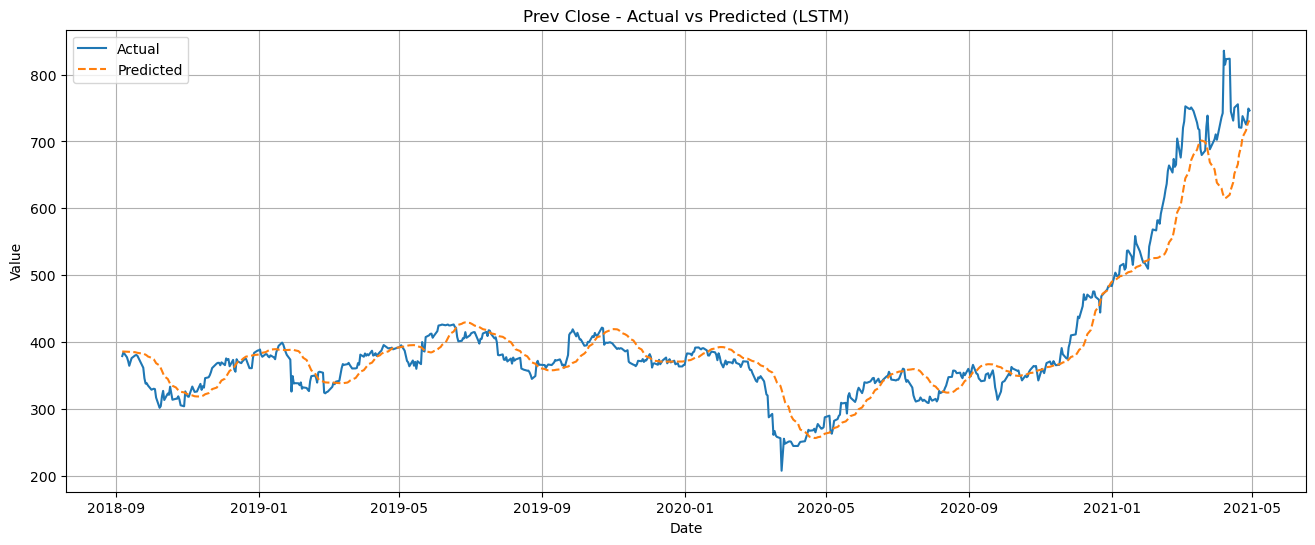

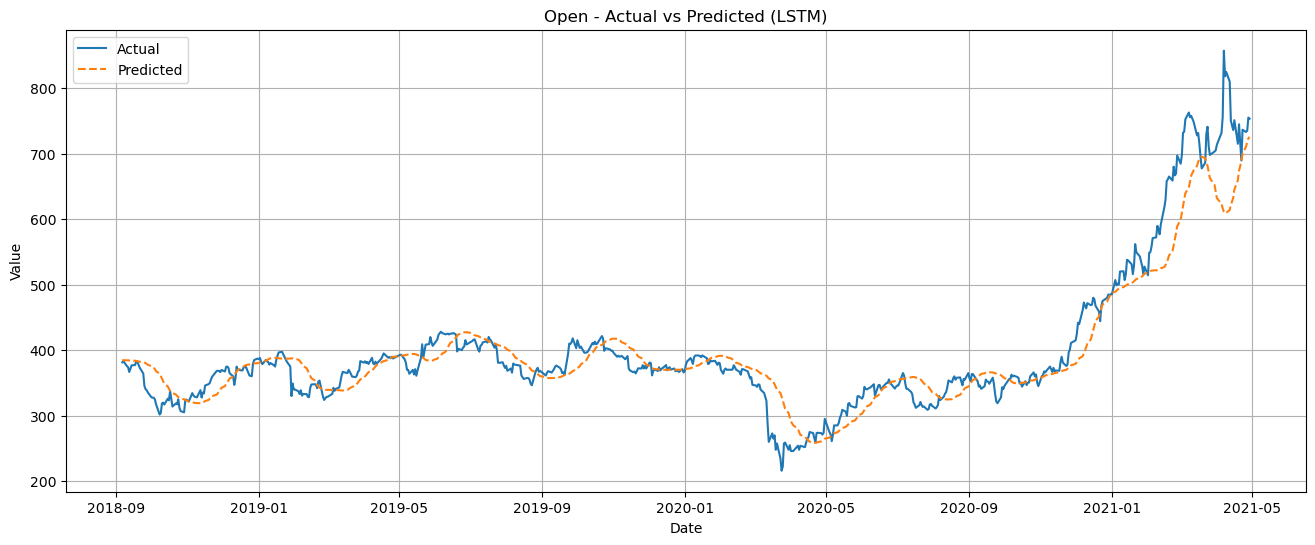

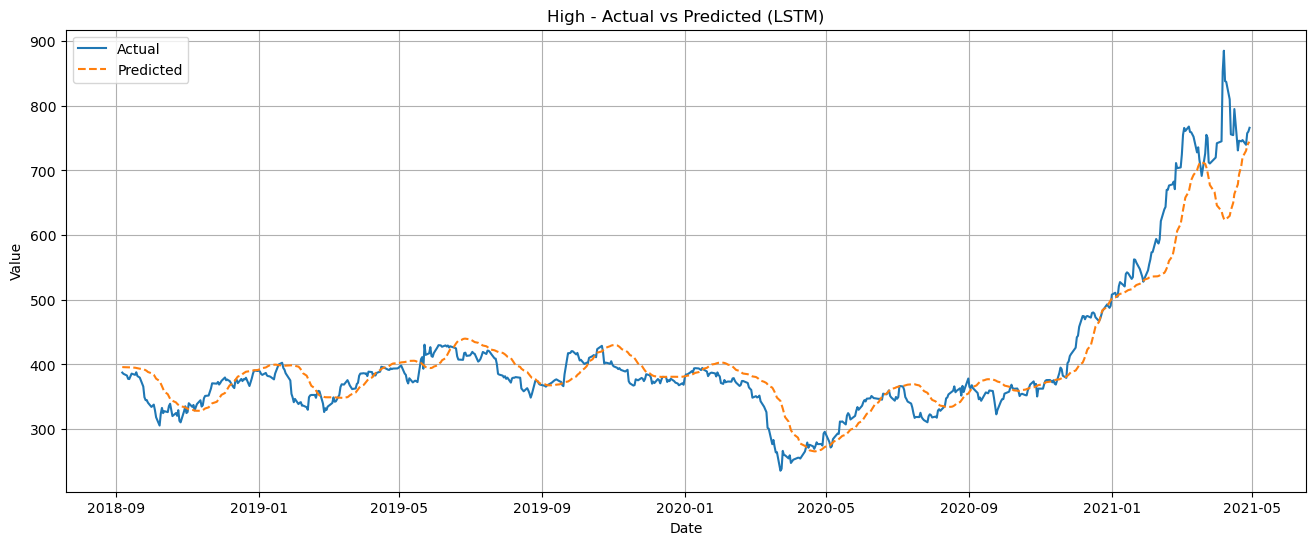

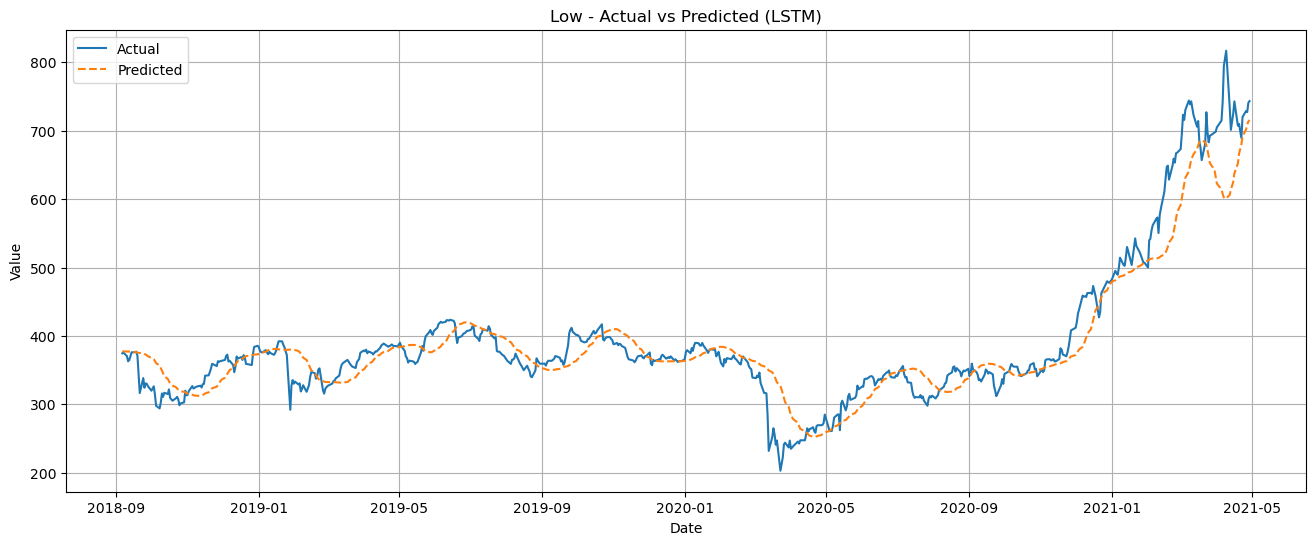

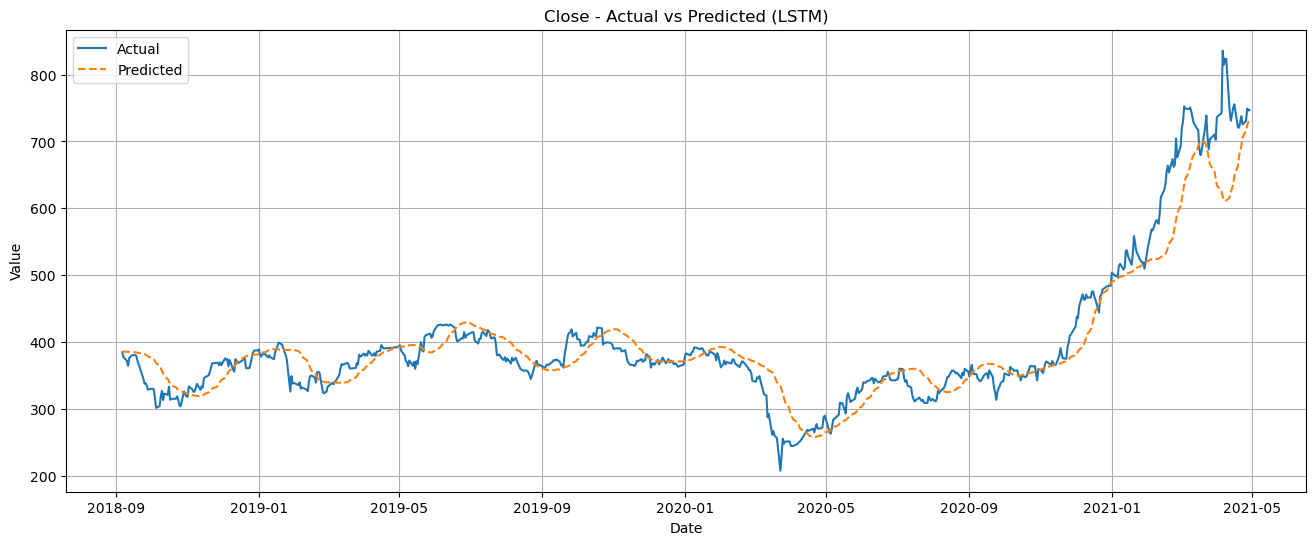

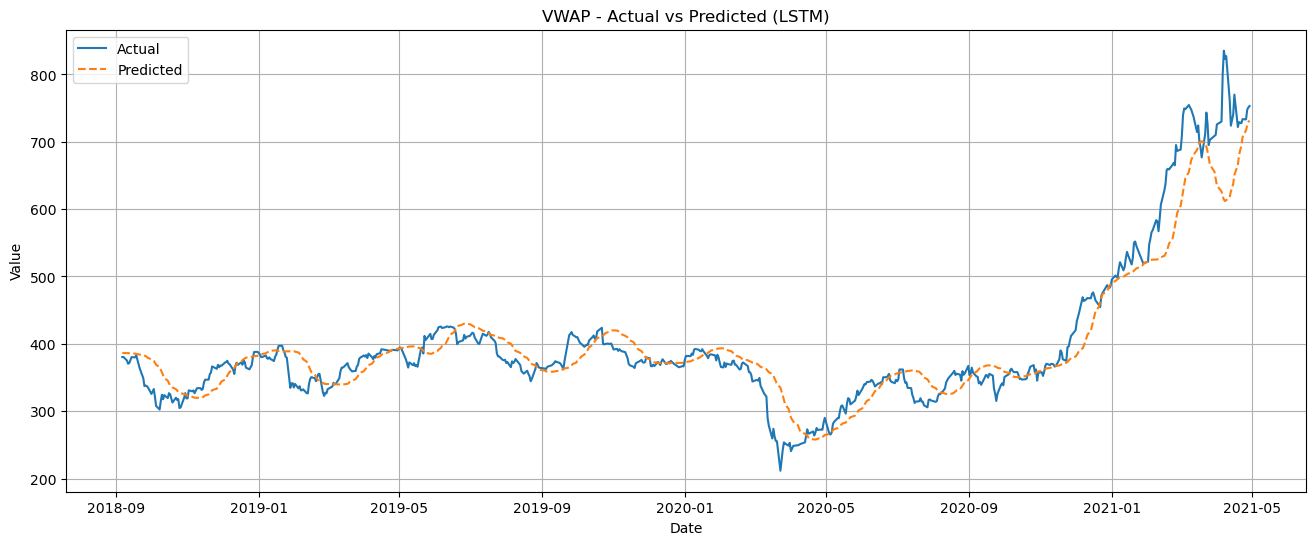

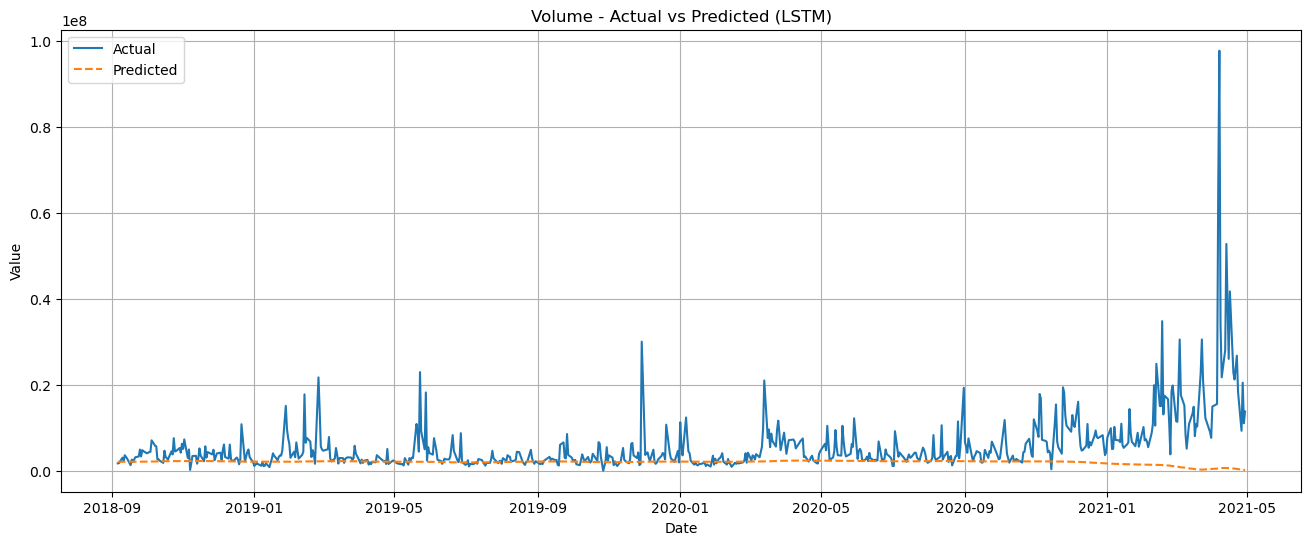

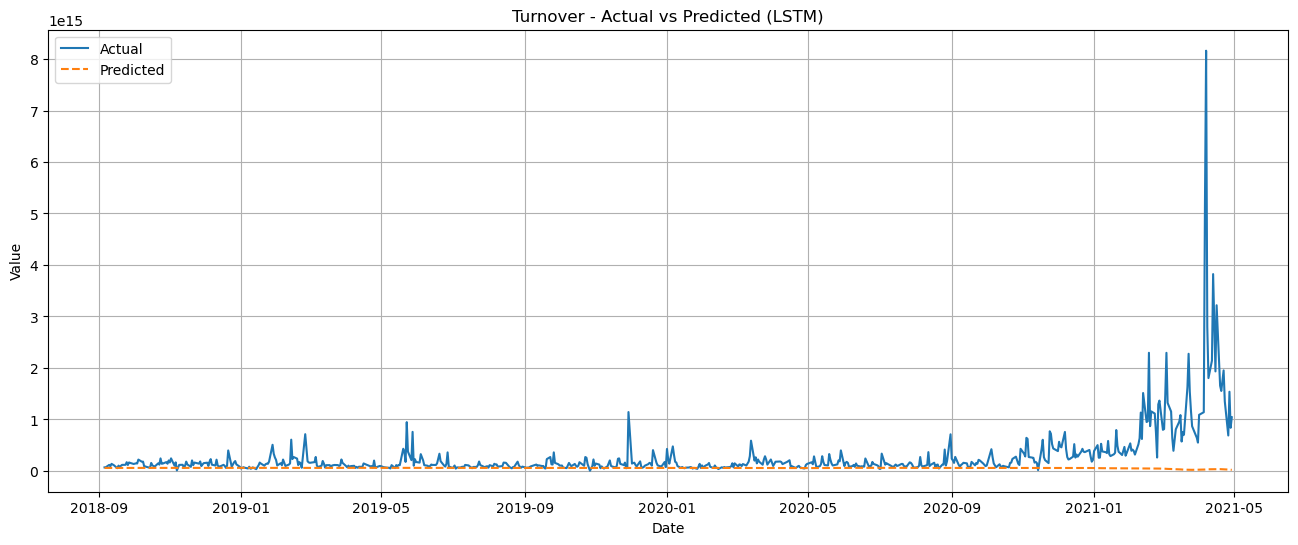

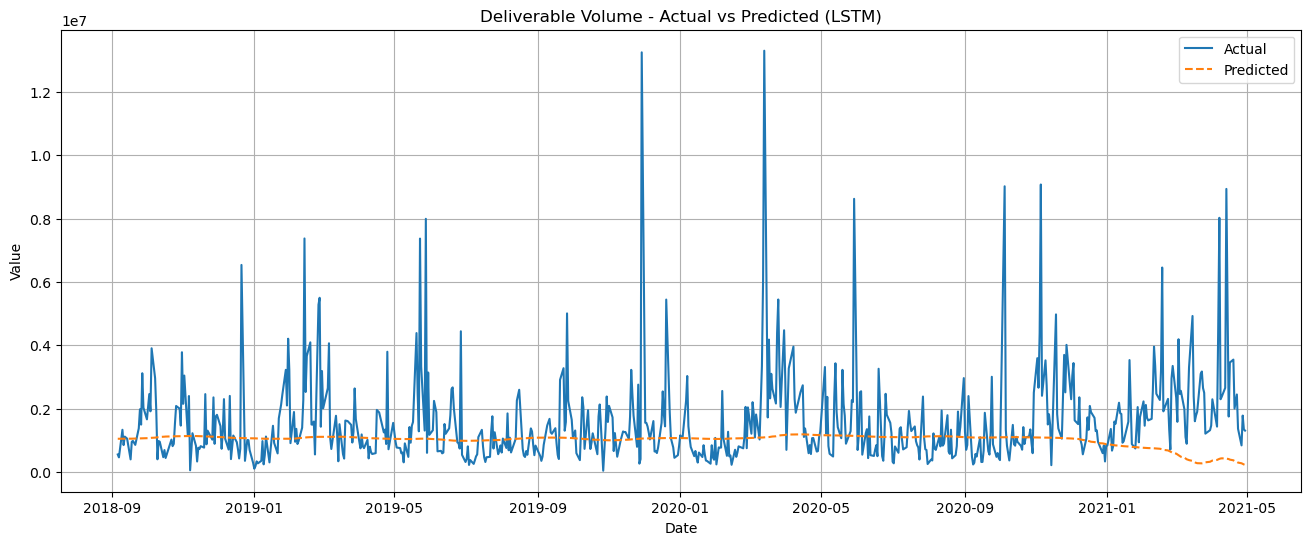

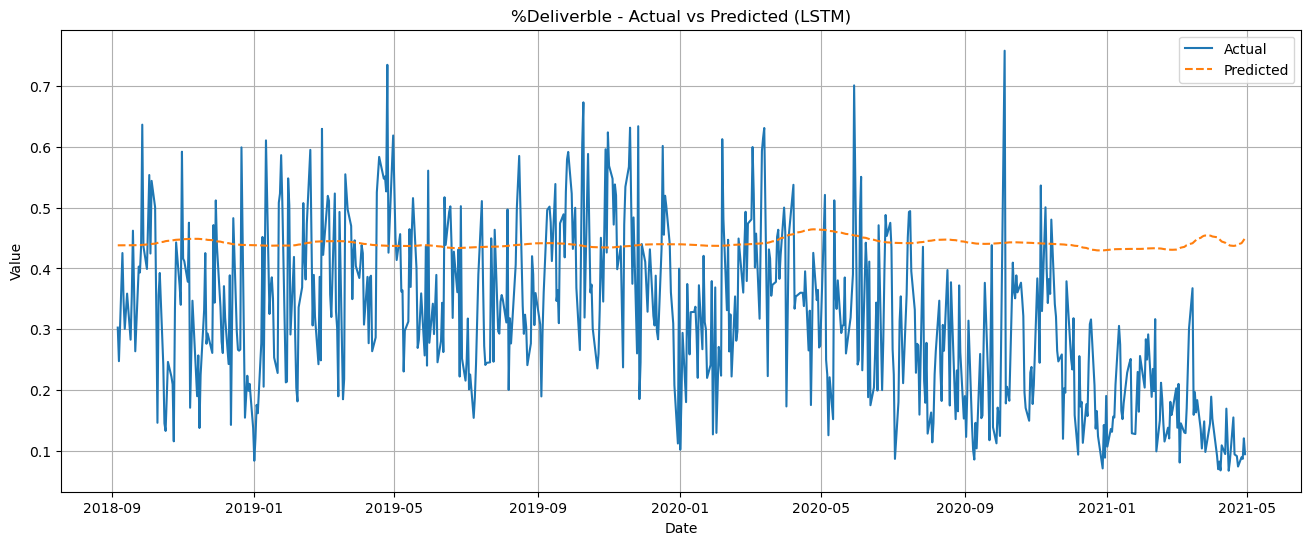

In [23]:
# Align predictions with actual data 
predicted_last_20 = pd.DataFrame(predictions[-num_samples: -1], columns=All_Columns, index=actual_last_20.index)

for columns in All_Columns:
    time_series_plot('LSTM', columns, predicted_last_20);

In [24]:
# Using RNN(Recurrent neural networks);model to predict 
RNNmodel = Sequential();
RNNmodel.add(Input(shape=(seq_length, len(All_Columns))));
RNNmodel.add(SimpleRNN(100, return_sequences=True))
RNNmodel.add(Dropout(0.3));
RNNmodel.add(SimpleRNN(100));
RNNmodel.add(Dropout(0.3));
RNNmodel.add(Dense(len(All_Columns)));
optimizer = Adam(learning_rate=0.001);

#Compile and fit the model
RNNmodel.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae', RootMeanSquaredError()]);
RNNmodel.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.2, callbacks=[early_stopping]);

Epoch 1/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.2185 - mae: 0.3574 - root_mean_squared_error: 0.4594 - val_loss: 0.0071 - val_mae: 0.0635 - val_root_mean_squared_error: 0.0845
Epoch 2/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0402 - mae: 0.1543 - root_mean_squared_error: 0.2001 - val_loss: 0.0037 - val_mae: 0.0400 - val_root_mean_squared_error: 0.0608
Epoch 3/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0196 - mae: 0.1059 - root_mean_squared_error: 0.1400 - val_loss: 0.0029 - val_mae: 0.0320 - val_root_mean_squared_error: 0.0541
Epoch 4/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0130 - mae: 0.0857 - root_mean_squared_error: 0.1138 - val_loss: 0.0027 - val_mae: 0.0288 - val_root_mean_squared_error: 0.0517
Epoch 5/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0103 - mae: 0.0750 - root_mean_squared_error: 0.1015 - val_loss: 0.0025 - val_mae: 0.0264 - val_root_mean_squared_error: 0.0502
Epoch 6/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/ste

In [25]:
# Make predictions
RNNpredictions = RNNmodel.predict(X_test);
RNNpredictions = scaler.inverse_transform(RNNpredictions);

# Convert predictions to DataFrame 
predictions_df_RNN = pd.DataFrame(RNNpredictions, columns=All_Columns, index=df.index[-len(RNNpredictions):]);

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [26]:
# Print RNN predict result
print_shape_result(predictions_df_RNN);

Predicted Results:
            Prev Close        Open        High         Low       Close  \
Date                                                                     
2018-09-06  386.156219  384.937744  396.100739  377.693176  386.015198   
2018-09-07  385.896179  384.691925  395.879456  377.465973  385.765045   
2018-09-10  385.750000  384.560394  395.770447  377.345856  385.633667   
2018-09-11  385.634094  384.462982  395.687042  377.249664  385.538818   
2018-09-12  385.499939  384.348999  395.575317  377.127869  385.427826   

                  VWAP      Volume      Turnover  Deliverable Volume  \
Date                                                                   
2018-09-06  386.647675  2181311.75  5.862343e+13        1.047302e+06   
2018-09-07  386.401703  2181740.75  5.864983e+13        1.047321e+06   
2018-09-10  386.270599  2182244.50  5.866989e+13        1.047336e+06   
2018-09-11  386.167572  2183117.25  5.867838e+13        1.047523e+06   
2018-09-12  386.043060  218440

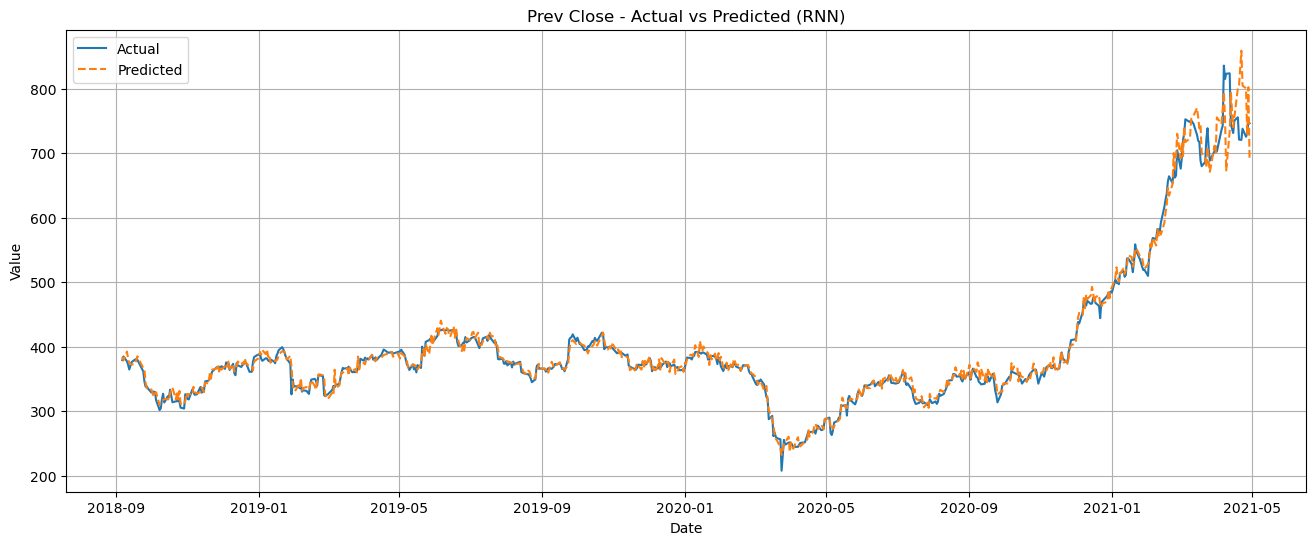

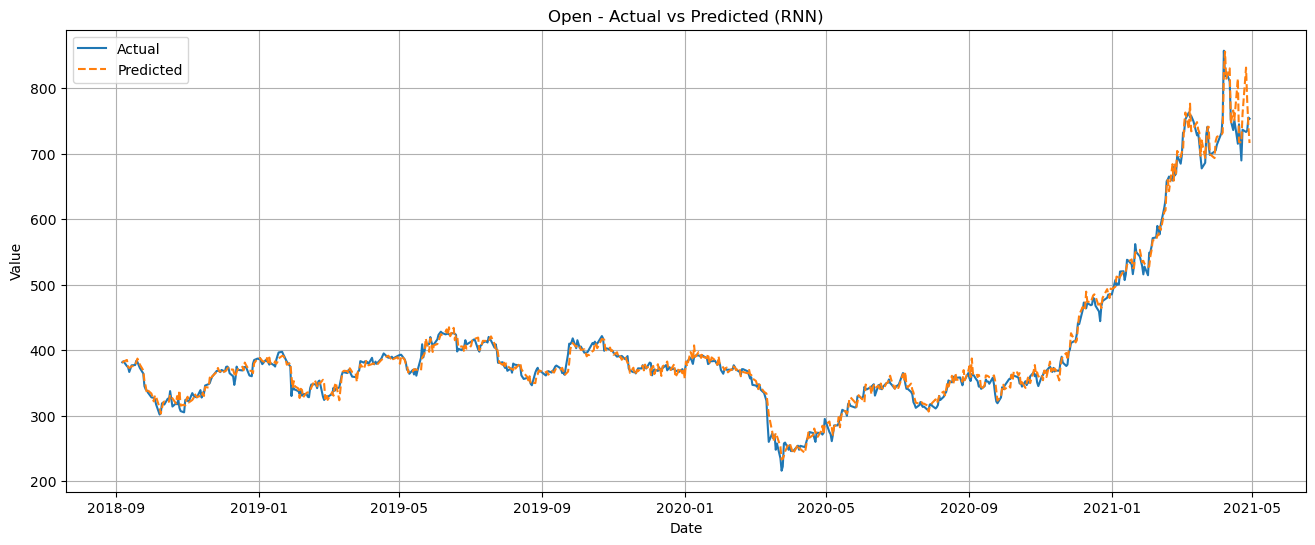

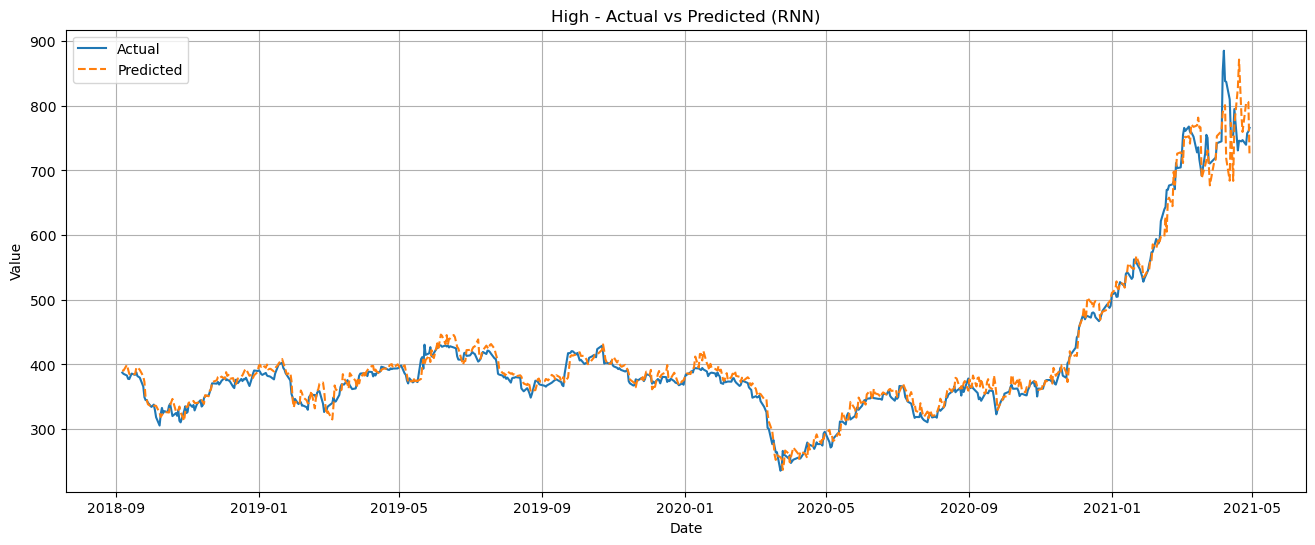

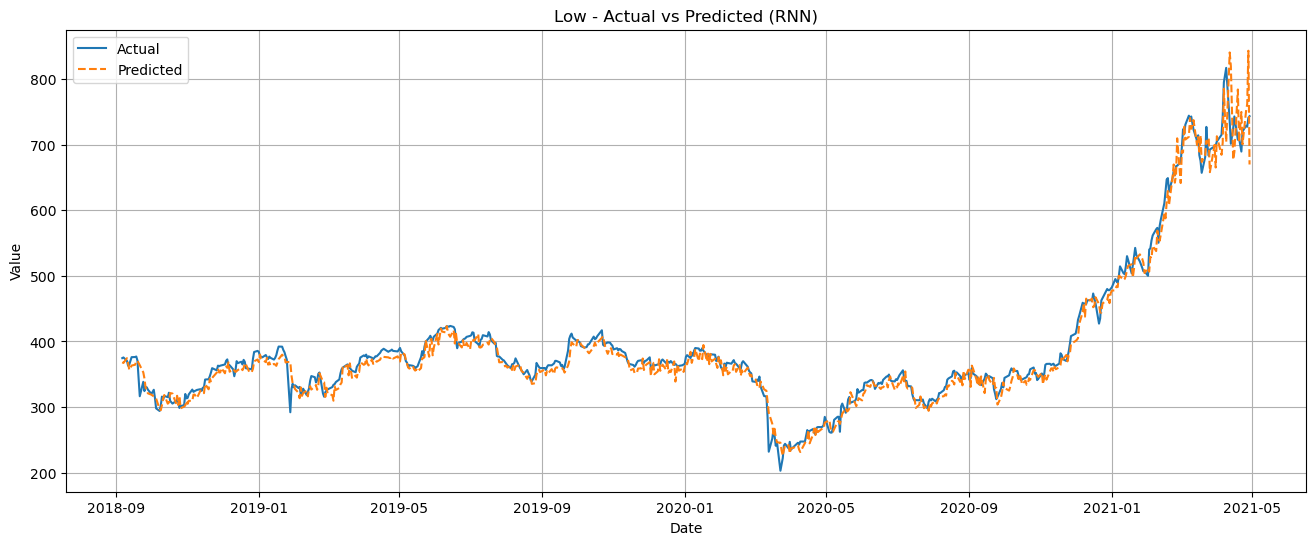

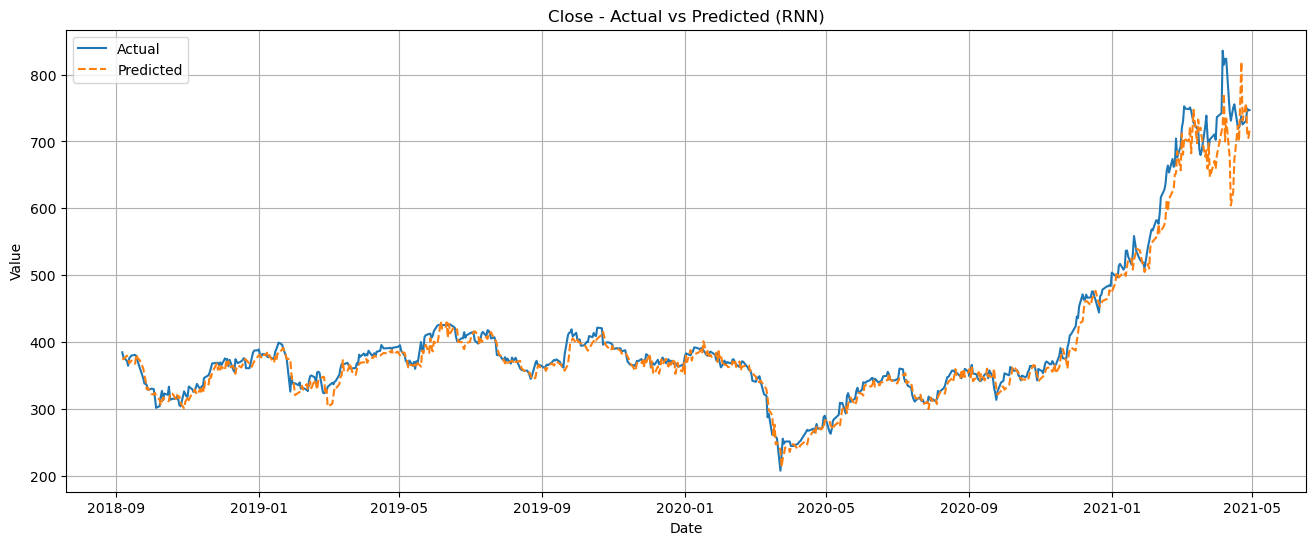

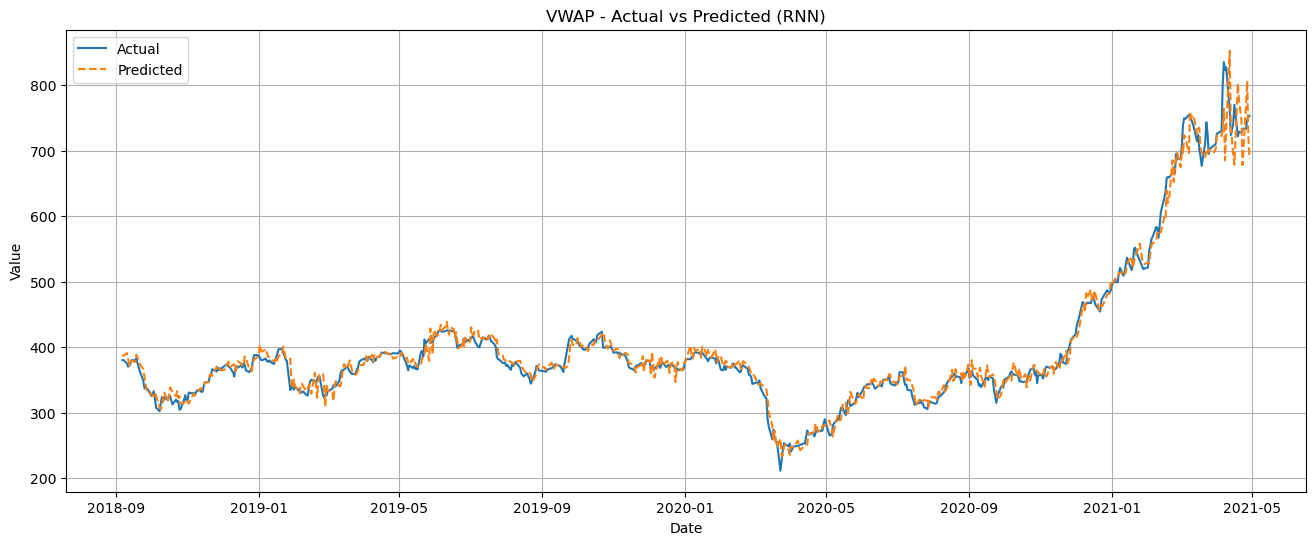

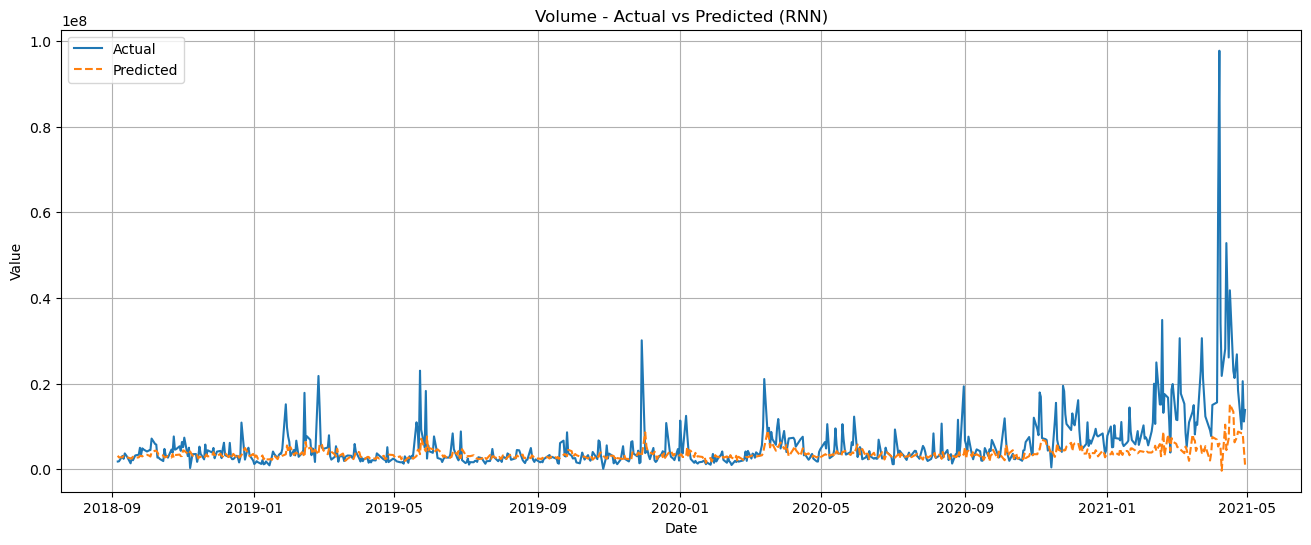

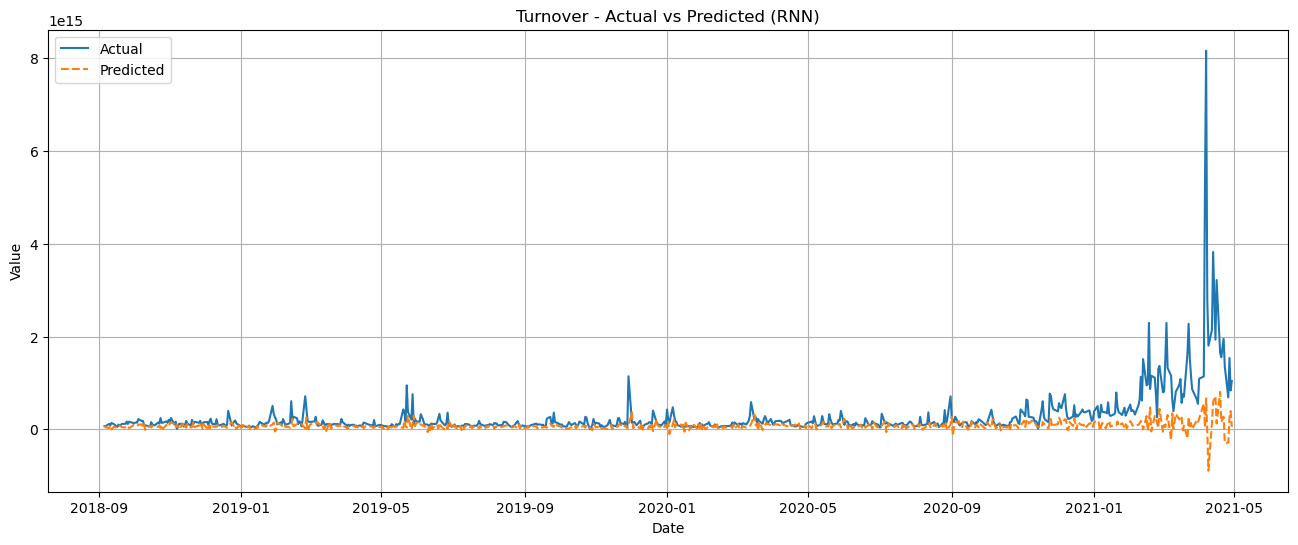

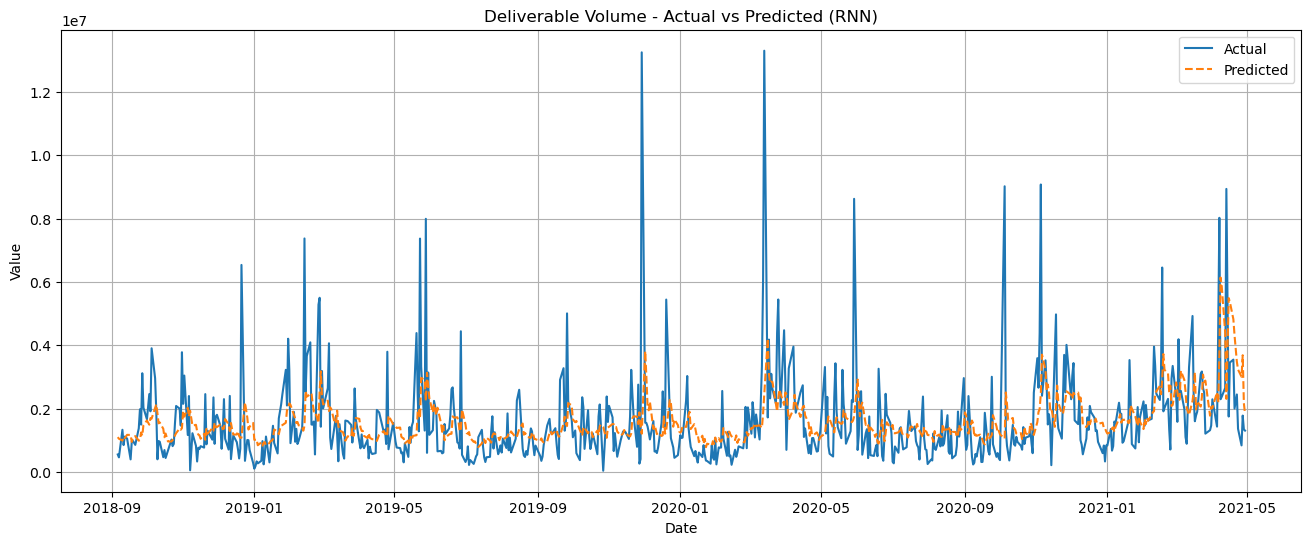

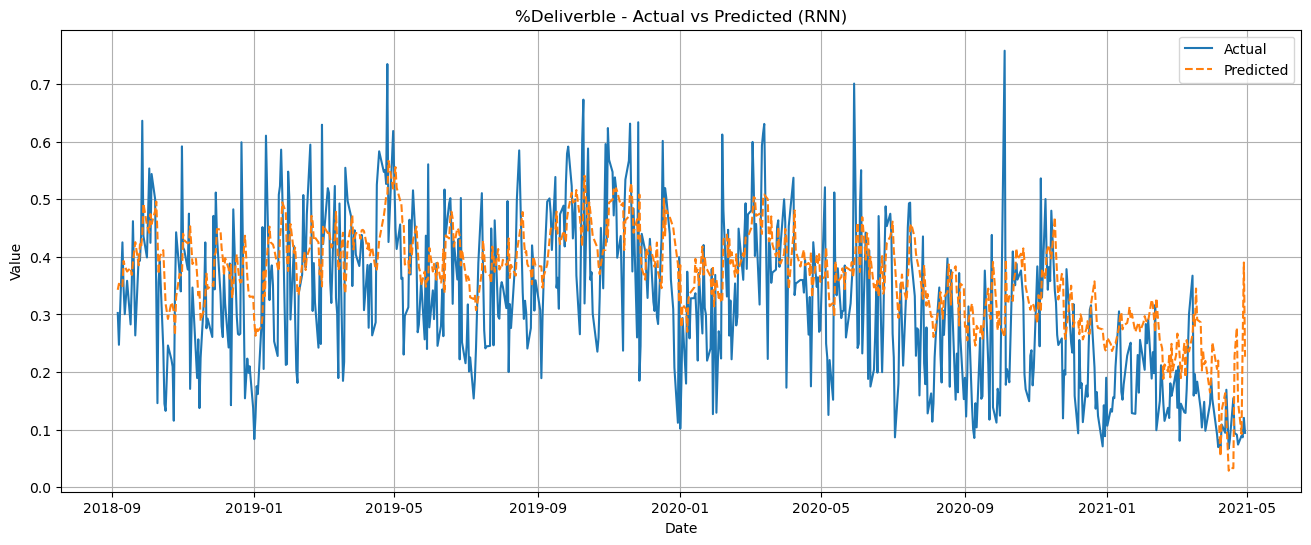

In [27]:
# Align predictions with actual data 
predicted_last_20_RNN = pd.DataFrame(RNNpredictions[-num_samples: -1], columns=All_Columns, index=actual_last_20.index);

for columns in All_Columns:
    time_series_plot('RNN', columns, predicted_last_20_RNN);

In [28]:
# using CNN (Convolutional Neural Networks);alogrithm to predict
CNNmodel = Sequential();
CNNmodel.add(Input(shape=(seq_length, len(All_Columns))));
CNNmodel.add(Conv1D(filters=64, kernel_size=2, activation='relu'));
CNNmodel.add(MaxPooling1D(pool_size=2));
CNNmodel.add(Flatten());
CNNmodel.add(Dense(100, activation='relu'));
CNNmodel.add(Dropout(0.3))
CNNmodel.add(Dense(100, activation='relu'));
CNNmodel.add(Dropout(0.3));
CNNmodel.add(Dense(len(All_Columns)));
optimizer = Adam(learning_rate=0.001);

#Compile and fit the model
CNNmodel.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae', RootMeanSquaredError()]);
CNNmodel.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.2, callbacks=[early_stopping]);

Epoch 1/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0240 - mae: 0.1066 - root_mean_squared_error: 0.1524 - val_loss: 0.0045 - val_mae: 0.0458 - val_root_mean_squared_error: 0.0669
Epoch 2/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0084 - mae: 0.0604 - root_mean_squared_error: 0.0914 - val_loss: 0.0033 - val_mae: 0.0327 - val_root_mean_squared_error: 0.0574
Epoch 3/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0064 - mae: 0.0514 - root_mean_squared_error: 0.0801 - val_loss: 0.0041 - val_mae: 0.0425 - val_root_mean_squared_error: 0.0643
Epoch 4/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062 - mae: 0.0506 - root_mean_squared_error: 0.0788 - val_loss: 0.0032 - val_mae: 0.0317 - val_root_mean_squared_error: 0.0567
Epoch 5/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0053 - mae: 0.0459 - root_mean_squared_error: 0.0729 - val_loss: 0.0033 - val_mae: 0.0313 - val_root_mean_squared_error: 0.0577
Epoch 6/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

In [29]:
# Make predictions
CNNpredictions = CNNmodel.predict(X_test);
CNNpredictions = scaler.inverse_transform(CNNpredictions);

# Convert predictions to DataFrame 
predictions_df_CNN = pd.DataFrame(CNNpredictions, columns=All_Columns, index=df.index[-len(CNNpredictions):]);

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [30]:
# Print RNN predict result
print_shape_result(predictions_df_CNN);

Predicted Results:
            Prev Close        Open        High         Low       Close  \
Date                                                                     
2018-09-06  386.156219  384.937744  396.100739  377.693176  386.015198   
2018-09-07  385.896179  384.691925  395.879456  377.465973  385.765045   
2018-09-10  385.750000  384.560394  395.770447  377.345856  385.633667   
2018-09-11  385.634094  384.462982  395.687042  377.249664  385.538818   
2018-09-12  385.499939  384.348999  395.575317  377.127869  385.427826   

                  VWAP      Volume      Turnover  Deliverable Volume  \
Date                                                                   
2018-09-06  386.647675  2181311.75  5.862343e+13        1.047302e+06   
2018-09-07  386.401703  2181740.75  5.864983e+13        1.047321e+06   
2018-09-10  386.270599  2182244.50  5.866989e+13        1.047336e+06   
2018-09-11  386.167572  2183117.25  5.867838e+13        1.047523e+06   
2018-09-12  386.043060  218440

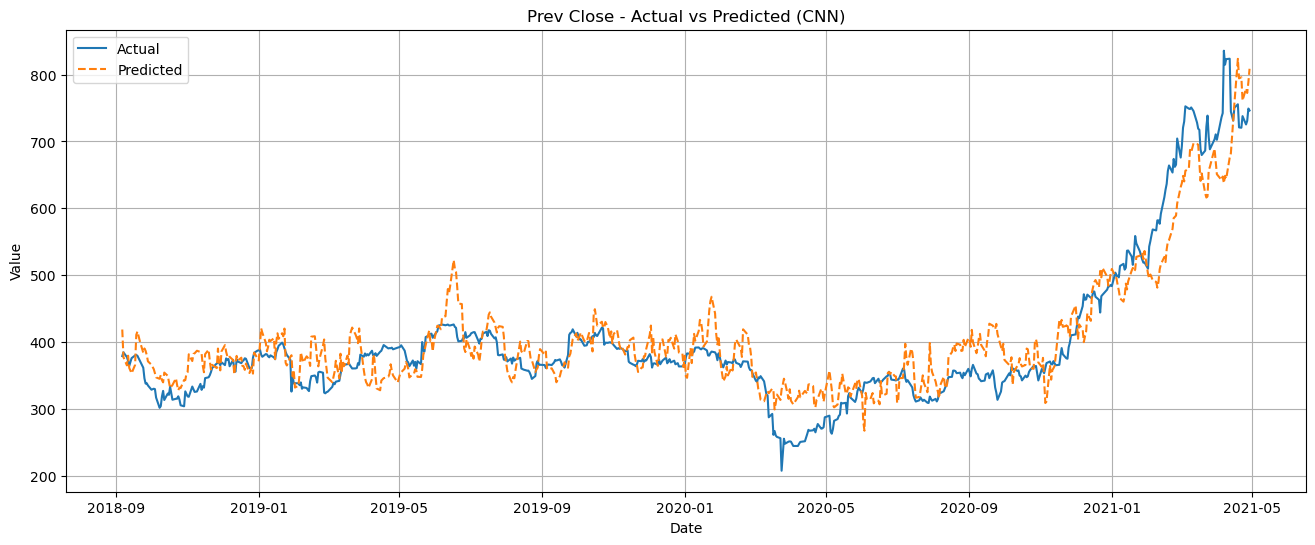

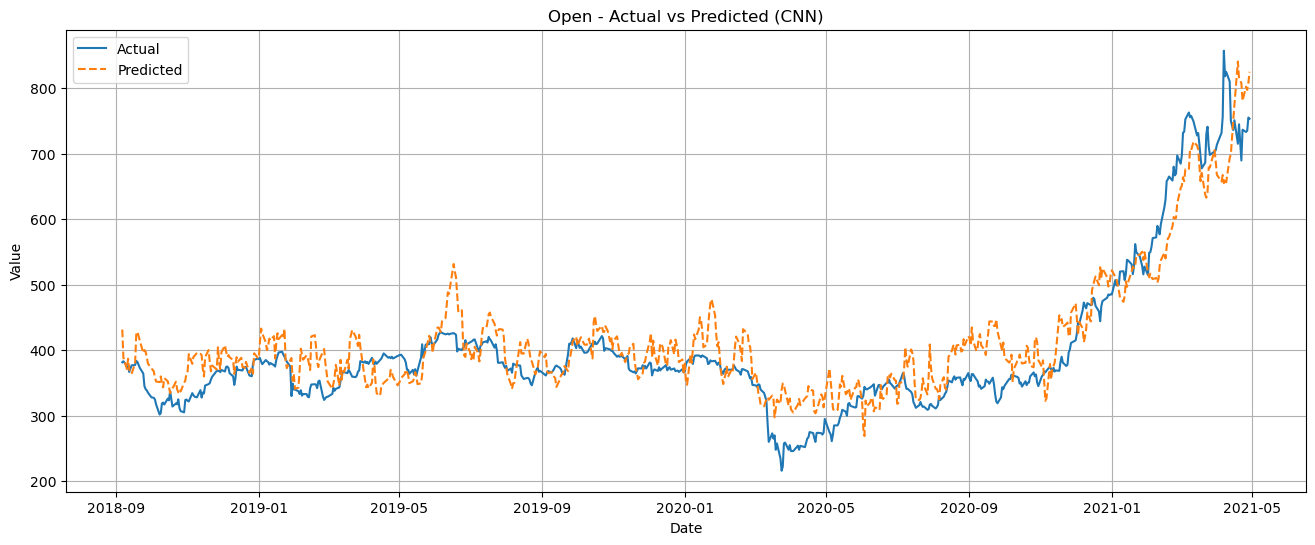

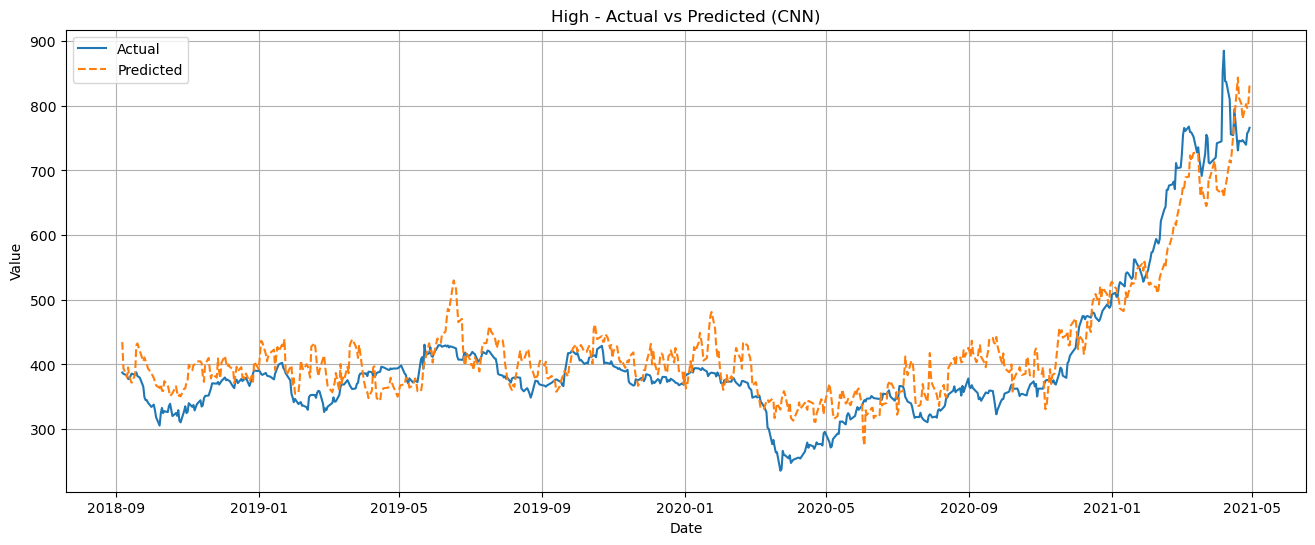

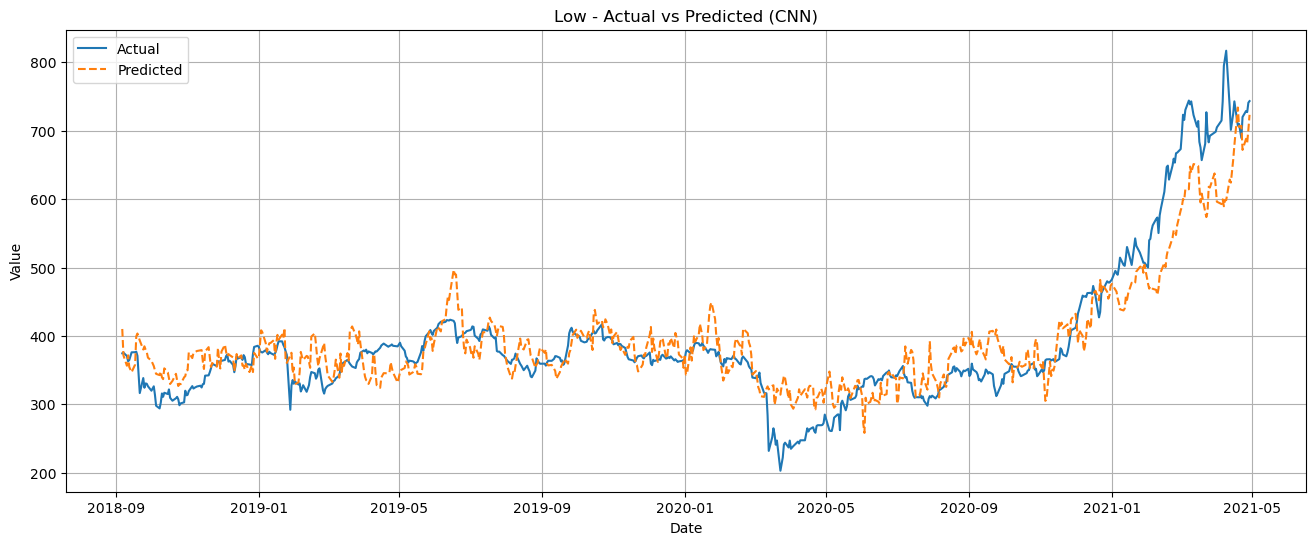

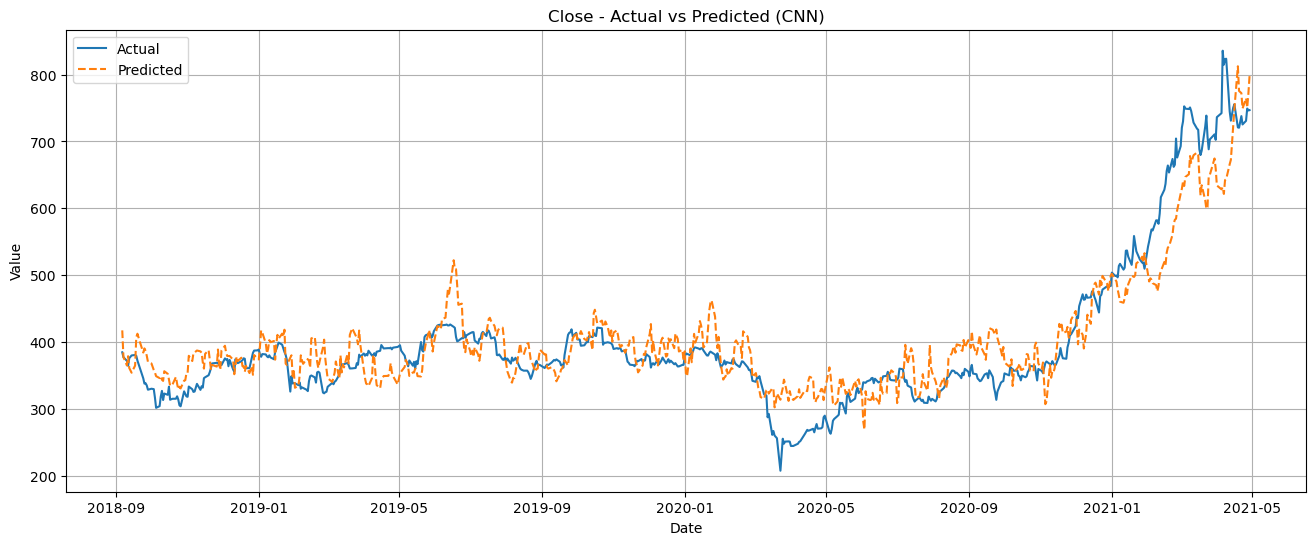

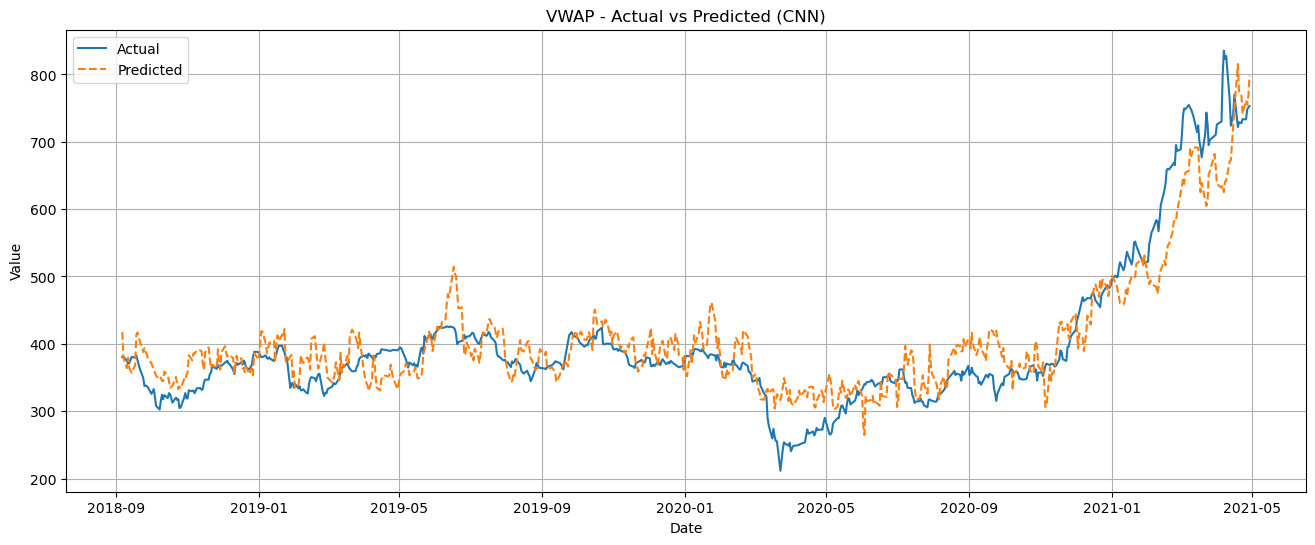

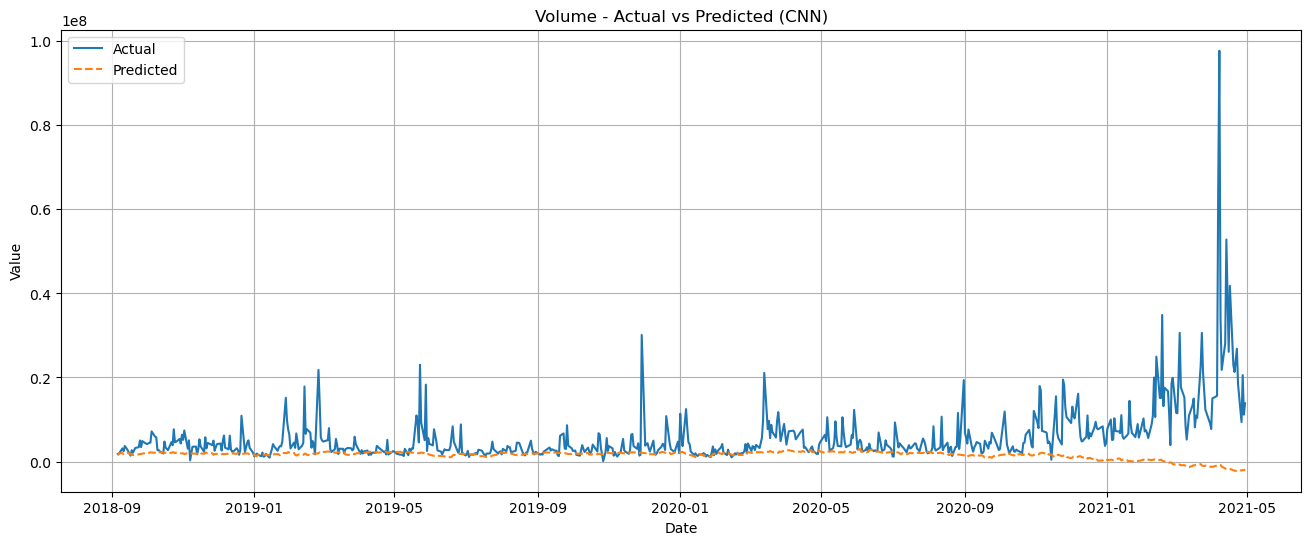

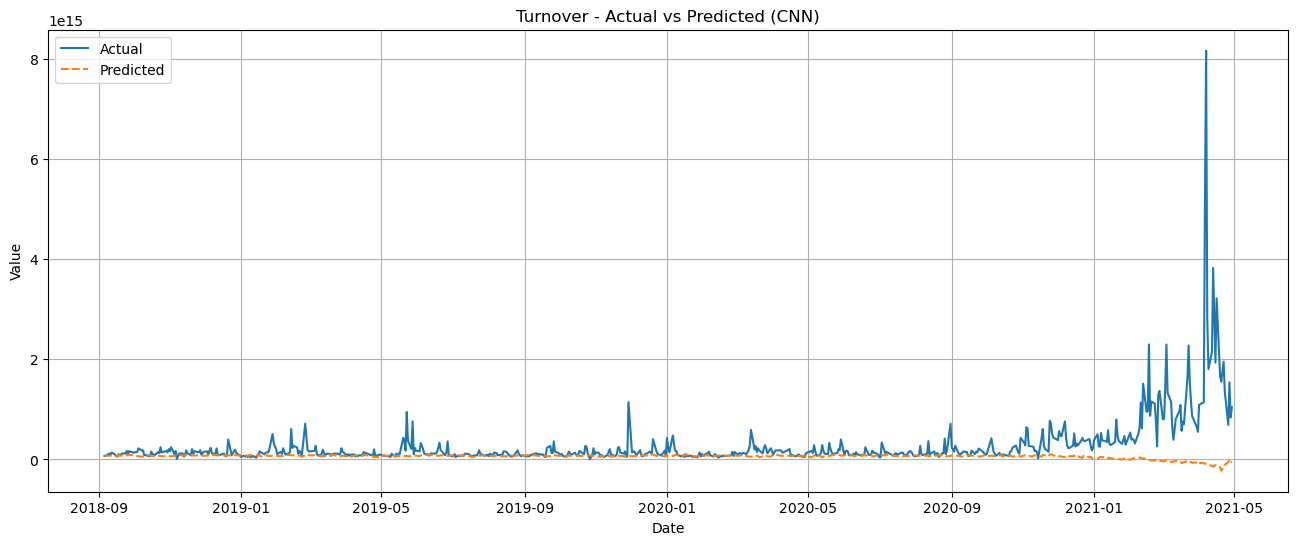

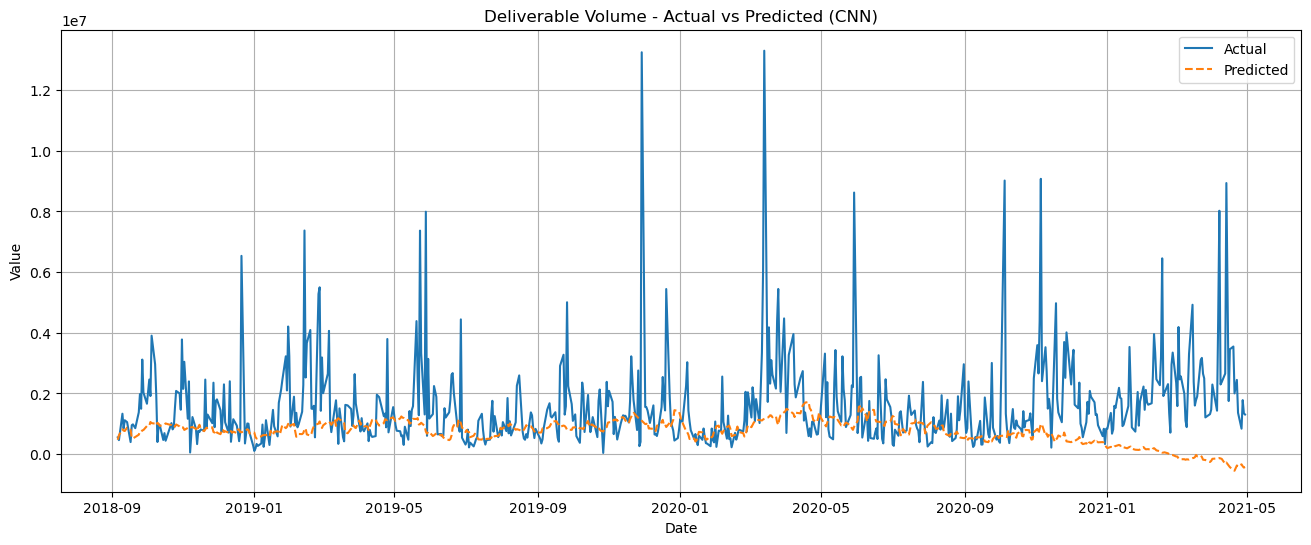

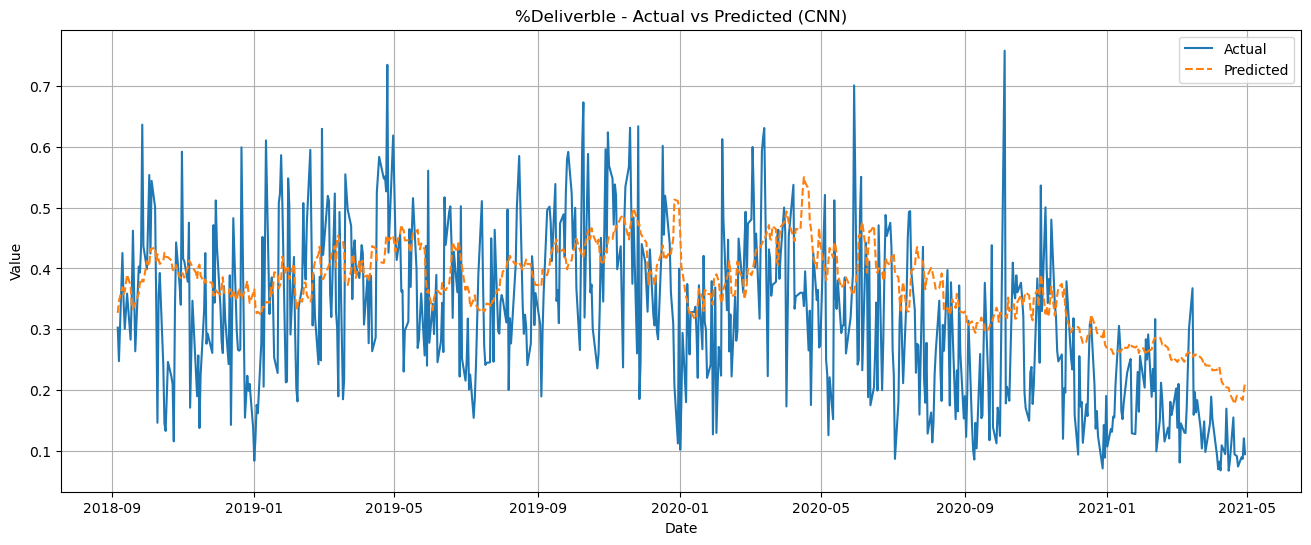

In [31]:
# Correct the slicing to include the last element
predicted_last_20_CNN = pd.DataFrame(CNNpredictions[-num_samples: -1], columns=All_Columns, index=actual_last_20.index);

# Print all the columns data with time series plot about the CNN result
for columns in All_Columns:
    time_series_plot('CNN', columns, predicted_last_20_CNN);

In [32]:
actual_df = actual_last_20;
models = ["LSTM", "RNN", "CNN"]

DataFrameMap = {
    "Actual" : actual_df[All_Columns],
    "LSTM" : predictions_df[All_Columns],
    "RNN" : predictions_df_RNN[All_Columns],
    "CNN" : predictions_df_CNN[All_Columns]
}

def compute_scores(dataMap, metric="MAE"): 
    scores = {} 
    for column in All_Columns: 
        actual_series = dataMap["Actual"][column] 
        for model_name, model_df in dataMap.items(): 
            if model_name != "Actual": 
                predict_series = model_df[column] 
                predict_series_aligned, actual_series_aligned = predict_series.align(actual_series, join='inner') 
                
                if metric == "MAE": 
                    scores[(column, model_name)] = mean_absolute_error(actual_series_aligned, predict_series_aligned) 
                elif metric == "RMSE": 
                    mse = mean_squared_error(actual_series_aligned, predict_series_aligned)
                    ## rmse =  the square root of mse
                    scores[(column, model_name)] = np.sqrt(mse) 
    return scores

def display_min_score(dataMap, score):
    data = {column: [score[(column, model)] for model in dataMap if model != "Actual"] for column in All_Columns} 
    df = pd.DataFrame(data, index=[m for m in dataMap if m != "Actual"])
    
    # highlight the min MAE(MEAN Absolute error) value
    return df.style.highlight_min(axis=0, color="green").format("{:.3f}")

In [33]:
MAE_scores = compute_scores(DataFrameMap, "MAE")

display_min_score(DataFrameMap, MAE_scores)

,Prev Close,Open,High,Low,Close,VWAP,Volume,Turnover,Deliverable Volume,%Deliverble
LSTM,23.066,23.821,24.670,23.693,24.493,23.975,3898228.543,221024322162335.656,933981.506,0.154
RNN,8.254,7.273,11.021,11.208,12.017,10.072,2957488.086,205766977868805.156,848437.542,0.099
CNN,31.866,35.193,36.090,33.155,32.908,32.744,4333428.582,220662851391961.375,1045495.881,0.106


In [34]:
RMSE_scores = compute_scores(DataFrameMap, "RMSE")

display_min_score(DataFrameMap, RMSE_scores)

,Prev Close,Open,High,Low,Close,VWAP,Volume,Turnover,Deliverable Volume,%Deliverble
LSTM,34.962,37.043,37.882,35.646,37.019,36.429,8164824.716,577469080930946.625,1593532.262,0.183
RNN,14.851,11.167,17.215,16.602,19.145,15.939,6848824.587,542879992319385.125,1382799.959,0.121
CNN,41.344,44.231,45.132,44.945,43.599,43.070,8664694.139,598127355755223.250,1740340.795,0.129


In [35]:
train, test = df[All_Columns].iloc[:num_training_samples], df[All_Columns].iloc[num_training_samples:] 

scaler = StandardScaler() 
train_scaled = pd.DataFrame(scaler.fit_transform(train), index=train.index, columns=train.columns) 
train_diff = train.diff().dropna() 
model = VAR(train_diff) 
model_fit = model.fit(maxlags=2)

lag_order = model_fit.k_ar 

input_data = train.values[-lag_order:] 
steps = len(test) 
VAR_forecast_diff = model_fit.forecast(y=input_data, steps=steps) 

VAR_forecast_diff = pd.DataFrame(VAR_forecast_diff, index=test.index, columns=All_Columns)
last_train = train.iloc[-1]

D:\Application\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [36]:
VAR_forecast_diff = model_fit.forecast(y=train_diff.values[-lag_order:], steps=len(actual_last_20)) 
VAR_forecast_cumsum = VAR_forecast_diff.cumsum(axis=0) 
VAR_forecast = VAR_forecast_cumsum + last_train.values 

predicted_last_20_VAR = pd.DataFrame(VAR_forecast, index=actual_last_20.index, columns=All_Columns) 
predicted_last_20_VAR.iloc[0] = last_train.values
print("Predictions:\n", predicted_last_20_VAR)

Predictions:
             Prev Close        Open        High         Low       Close  \
Date                                                                     
2018-09-06  380.500000  384.000000  387.700000  380.100000  382.300000   
2018-09-07  382.532892  384.467074  386.721422  379.062315  382.220711   
2018-09-10  382.220711  383.199795  386.543159  379.194498  381.923040   
2018-09-11  381.923041  383.101275  386.434436  378.867368  381.902498   
2018-09-12  381.902498  383.322512  386.130467  378.739159  381.609265   
...                ...         ...         ...         ...         ...   
2021-04-23  249.338671  248.966903  242.736149  255.829983  249.132616   
2021-04-26  249.132623  248.758347  242.513112  255.638860  248.926568   
2021-04-27  248.926576  248.549790  242.290075  255.447737  248.720520   
2021-04-28  248.720528  248.341234  242.067038  255.256613  248.514473   
2021-04-29  248.514480  248.132678  241.844001  255.065490  248.308425   

                  VWAP 

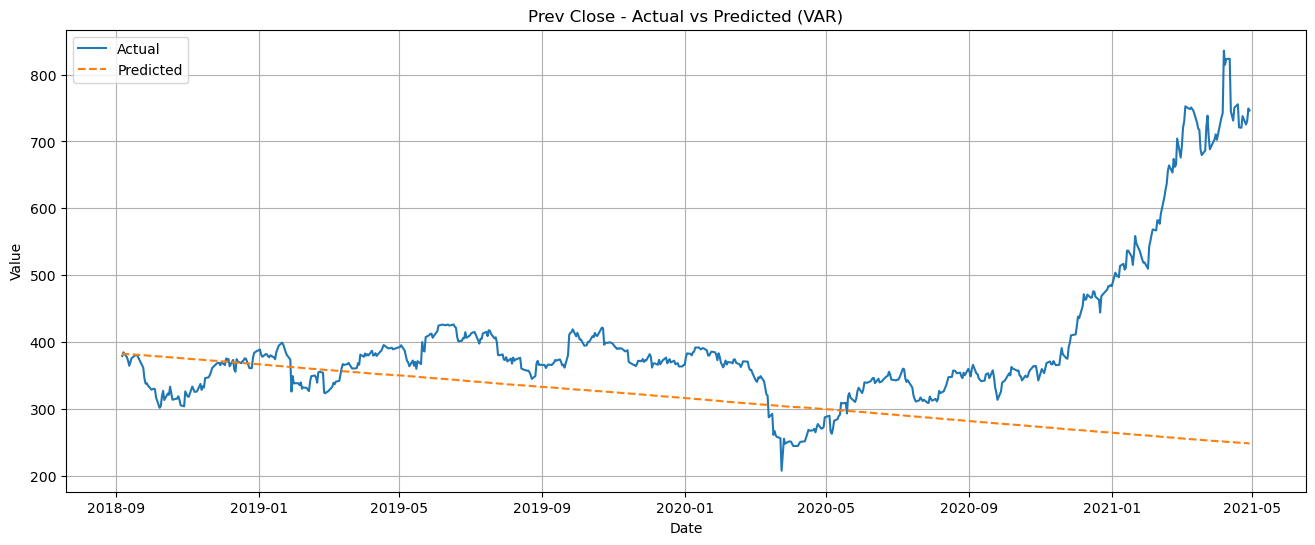

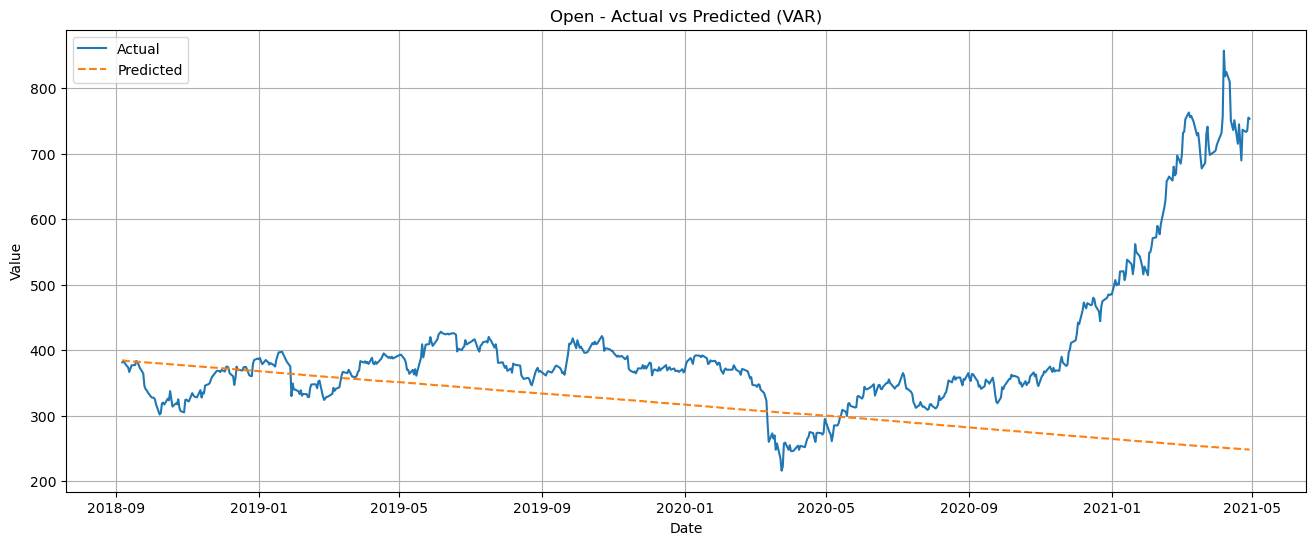

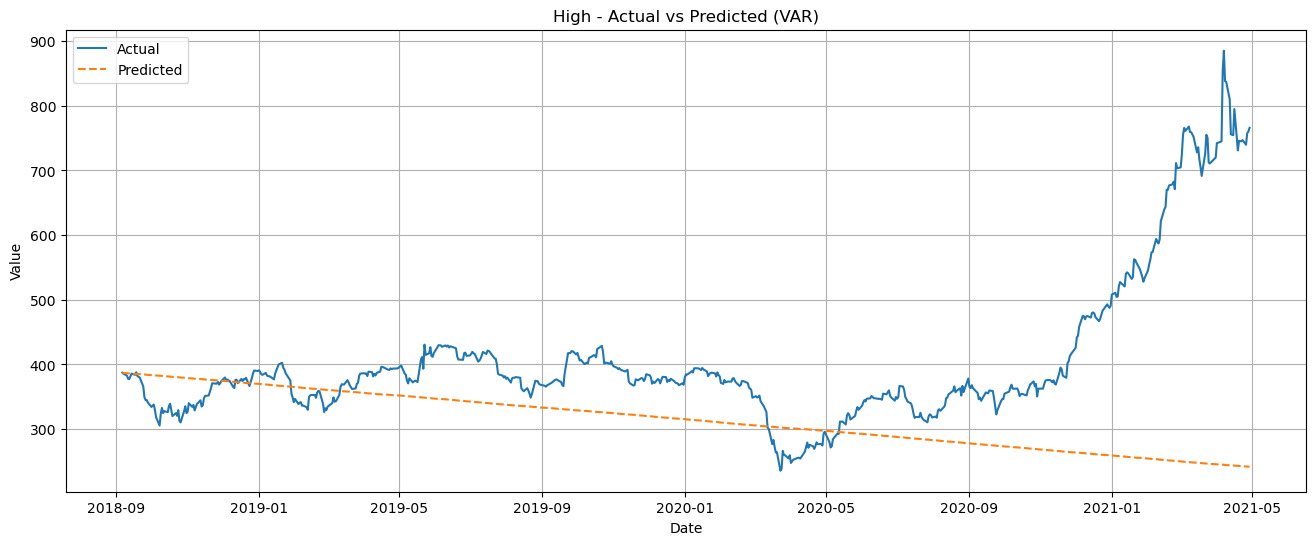

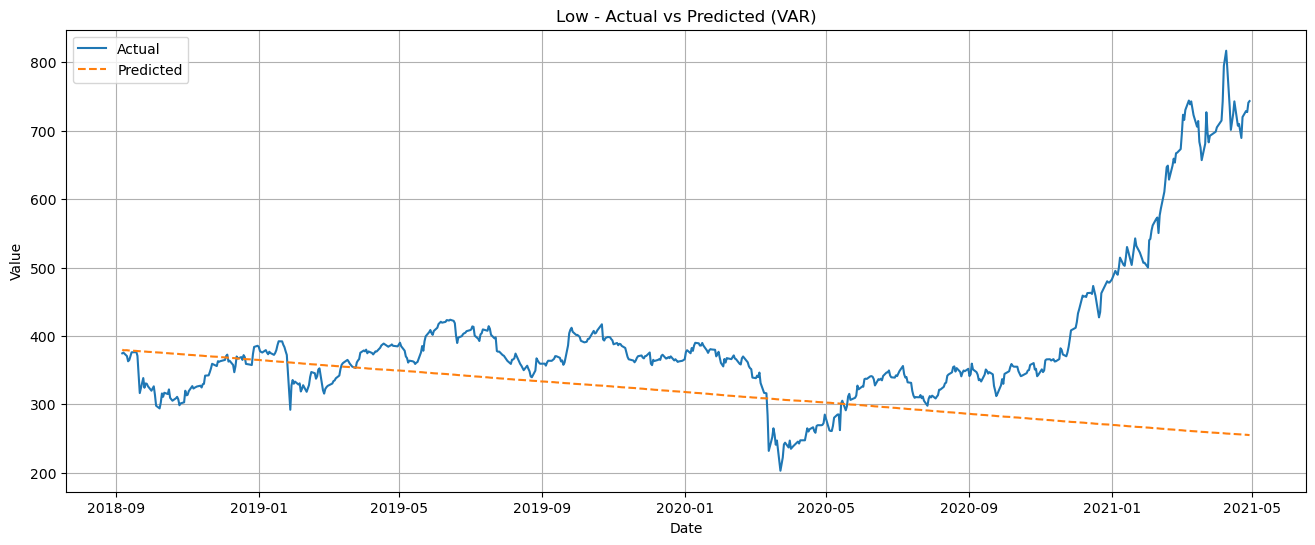

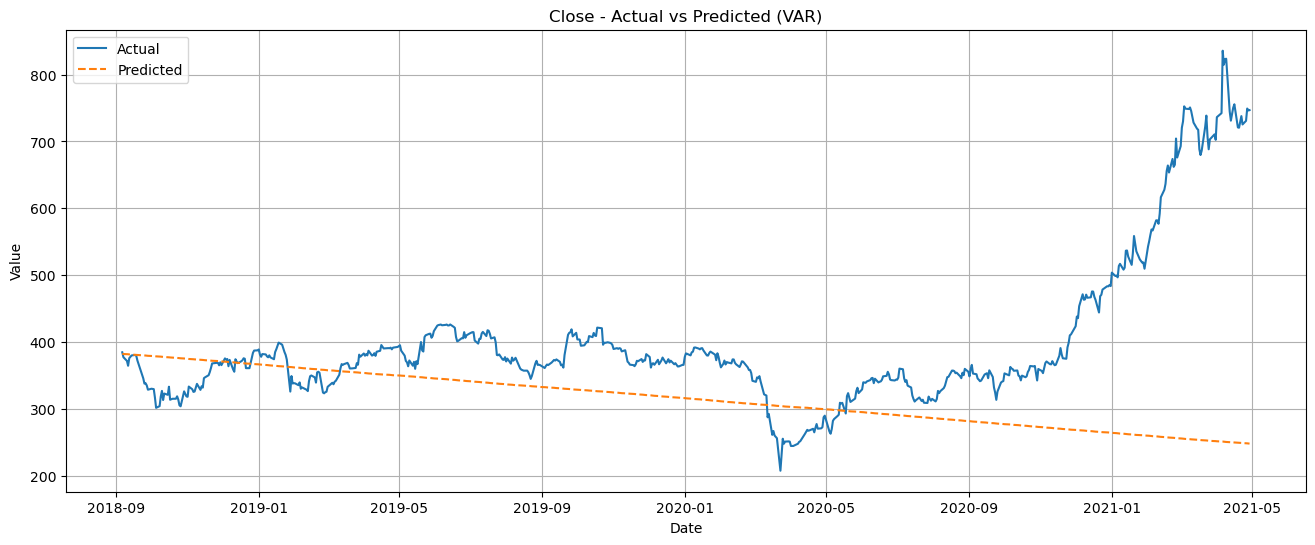

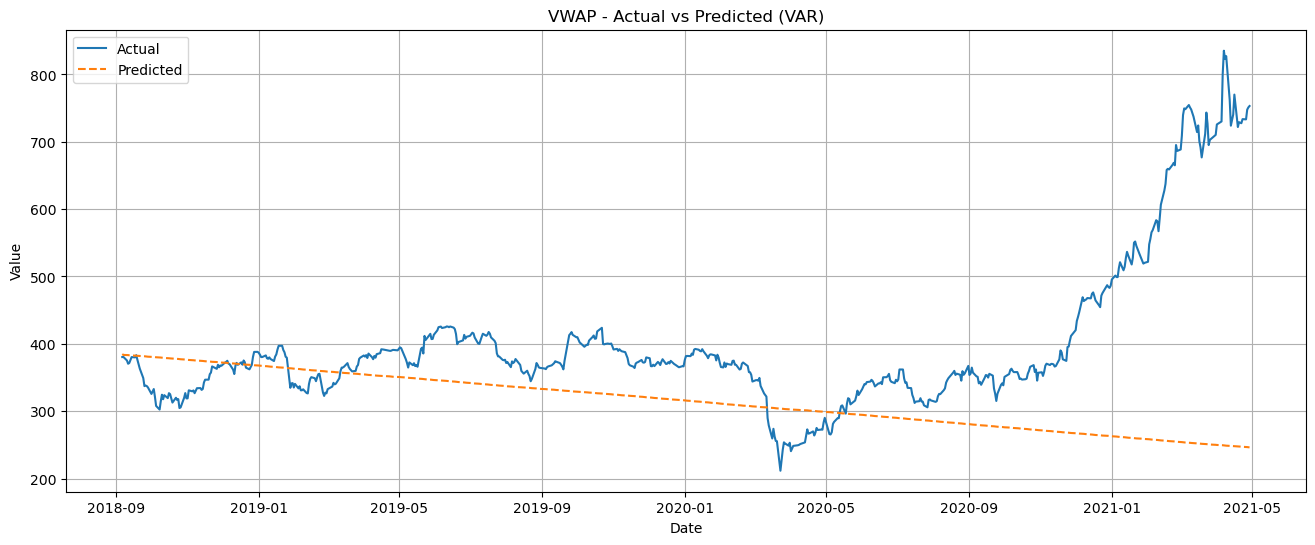

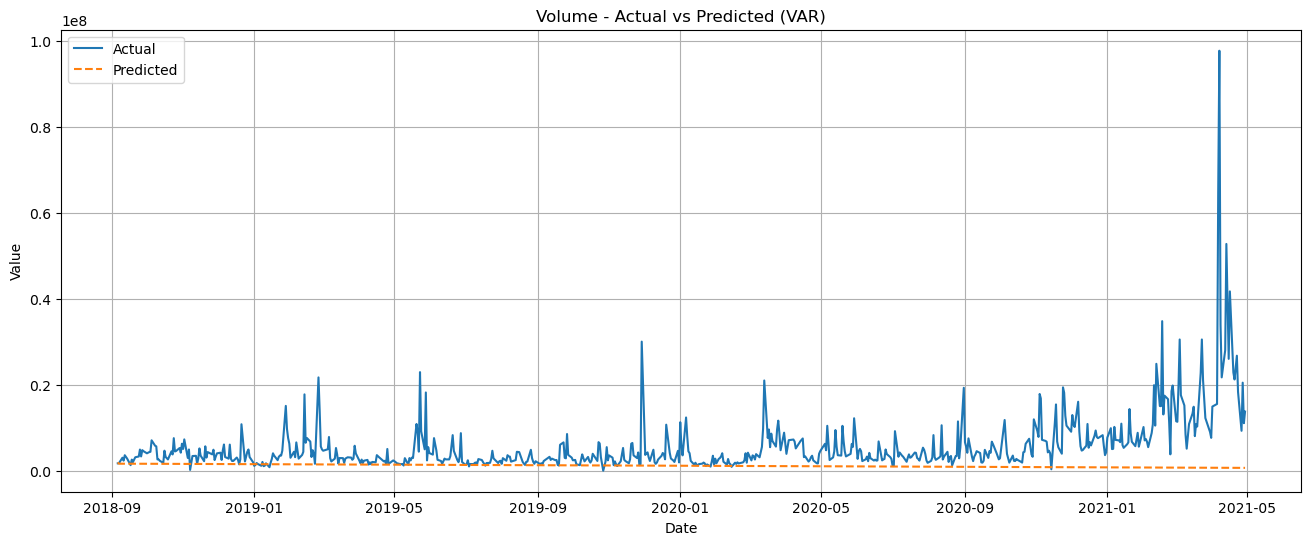

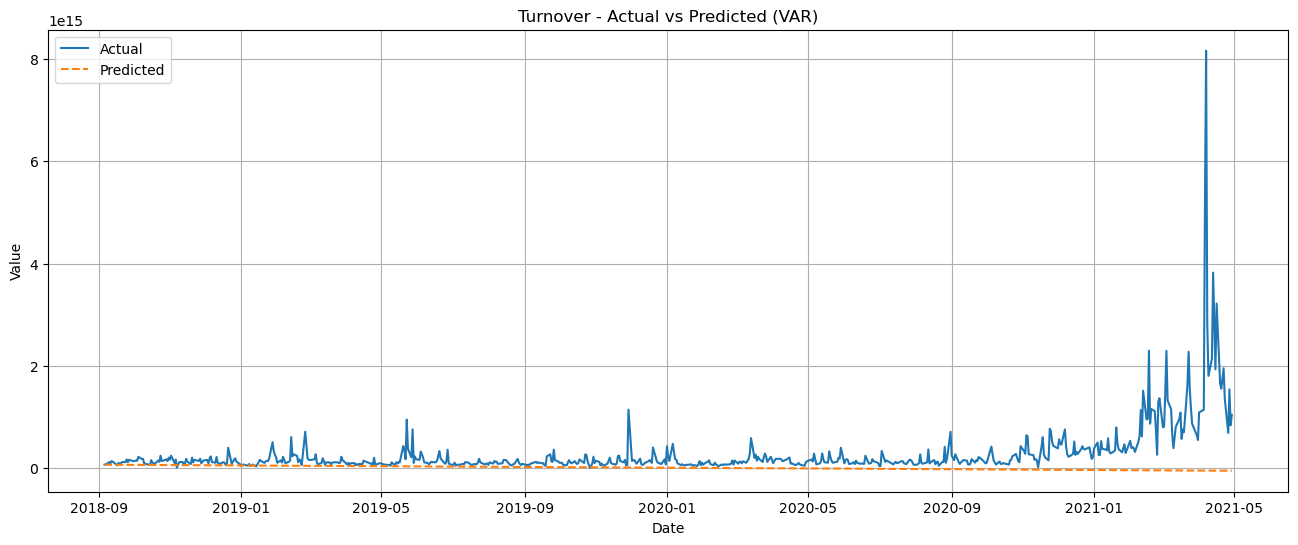

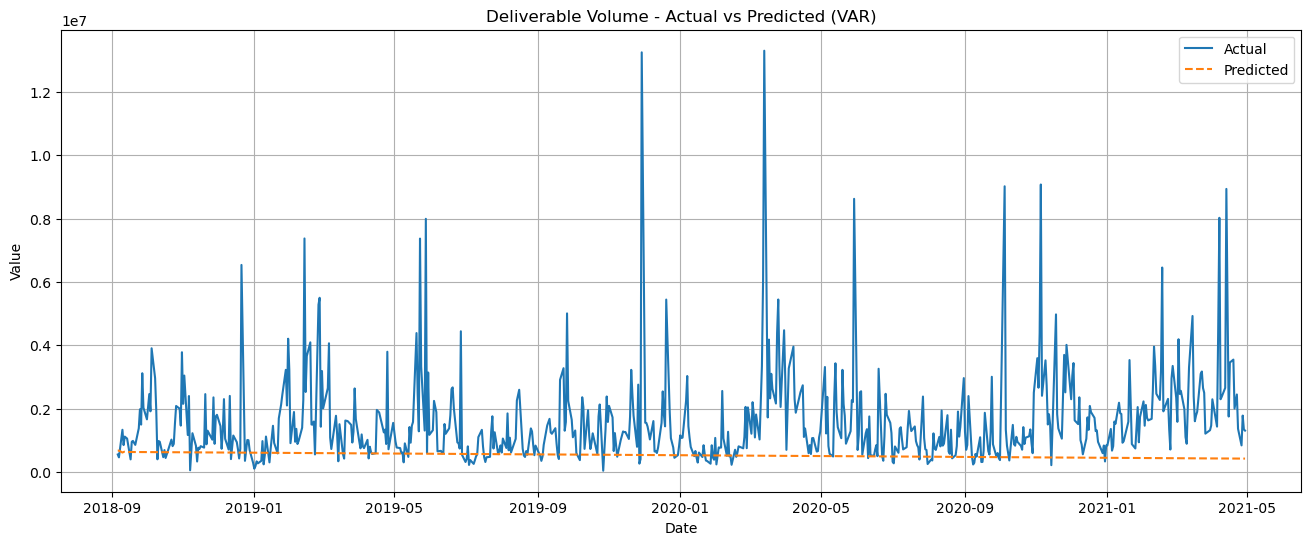

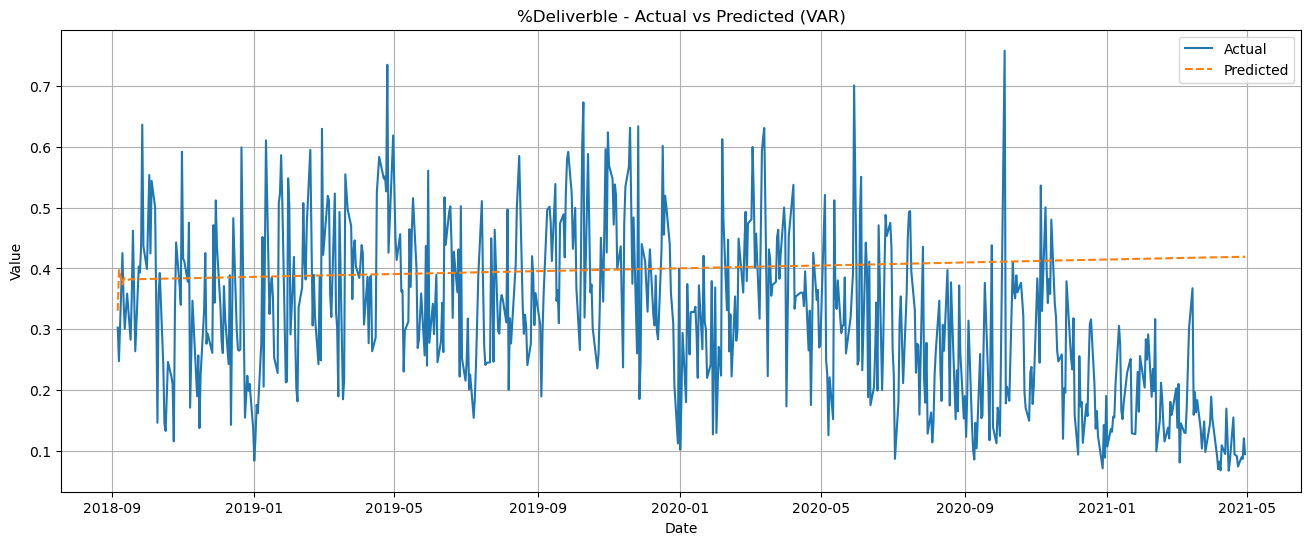

In [37]:
for columns in All_Columns:
    time_series_plot('VAR', columns, predicted_last_20_VAR);

In [38]:
compareDataMap = {
    "Actual" : actual_df[All_Columns],
    "RNN": predictions_df_RNN[All_Columns],
    "VAR" : predicted_last_20_VAR[All_Columns]
}

compare_MAE_scores = compute_scores(compareDataMap, "MAE")

display_min_score(compareDataMap, compare_MAE_scores)

,Prev Close,Open,High,Low,Close,VWAP,Volume,Turnover,Deliverable Volume,%Deliverble
RNN,8.254,7.273,11.021,11.208,12.017,10.072,2957488.086,205766977868805.156,848437.542,0.099
VAR,93.760,94.602,100.129,88.685,94.523,95.233,4575375.514,268616564585373.062,1109068.252,0.136


In [39]:
compare_RMSE_scores = compute_scores(compareDataMap, "RMSE")

display_min_score(compareDataMap, compare_RMSE_scores)

,Prev Close,Open,High,Low,Close,VWAP,Volume,Turnover,Deliverable Volume,%Deliverble
RNN,14.851,11.167,17.215,16.602,19.145,15.939,6848824.587,542879992319385.125,1382799.959,0.121
VAR,153.629,154.869,163.220,146.290,154.864,155.827,8462672.289,606253654216960.875,1801414.105,0.163


In [40]:
predictResults = [predicted_last_20, predicted_last_20_RNN, predicted_last_20_CNN, predicted_last_20_VAR];
path = "./PredictData/";
fileNames = ["LSTM_PredictResult_Stock.csv", "RNN_PredictResult_Stock.csv", "CNN_PredictResult_Stock.csv", "VAR_PredictResult_Stock.csv"]

for predictResult, fileName in zip(predictResults, fileNames):
    predictResult.to_csv(path + fileName, index="false");

In [41]:
metricsData = [MAE_scores, RMSE_scores, compare_MAE_scores, compare_RMSE_scores]
metricsFileNames = ["MAE_metrics.csv", "RMSE_metrics.csv", "MAE_Between_RNN_And_VAR.csv", "RMSE_Between_RNN_And_VAR.csv"]

for metricData, metricsFileName in zip(metricsData, metricsFileNames):
    df = pd.DataFrame.from_dict(metricData, orient="index", columns=["score"])
    
    if isinstance(next(iter(metricData.keys())), tuple):
        df.index = pd.MultiIndex.from_tuples(df.index, names=["Column", "Model"])
    
    df.to_csv(path + metricsFileName, index=True)